# Static Card2Vec research report — frozen v2 and relation-aware v3

**Research questions.** What do input and context vectors encode? Do similarity,
substitution, complementarity and concept completion prefer different scorers?
Does SGNS add value beyond incidence, PMI and PPMI-SVD, after inspecting popularity?
128d remains the reference; 256d is the existing comparison, not an assumed improvement.

**Report map.** The original v2 cells below preserve dataset provenance, quality,
training configuration and saved representation/retrieval results verbatim. The original
v3 section is a **historical partial snapshot**, also preserved verbatim. The final
**Relation-aware v3.1** section supplies the revised benchmark, consistent metrics,
small compatibility probe, stability, qualitative inspection and next-experiment controls.
No downstream recommender is implemented here.

**Established:** saved v2 and historical v3 measurements. **Hypothesis:** input cosine
may emphasize similar roles while cross-space scores emphasize association. **Limitation:**
the old semantic benchmark covered only two directed queries, so it cannot establish
that hypothesis. Newly generated labels and pending computations are not new results.
The appended **v3.2 fusion and downstream export** section reports the completed fusion comparison and portable per-seed checkpoints.


# Static Card2Vec — second experiment: 128 vs 256

This notebook reuses the existing packed corpus, normalization, metadata, bounded unordered-pair
SGNS trainer, and joblib infrastructure. It focuses on **three independent training seeds per dimension**,
cleaner targets/contexts, and uncertainty. It does not rerun the original 128–1024 sweep.

The targeted CLI runs only the requested stages. Review cells below read its saved outputs; training
and evaluation cells are **opt-in**. Original models/results and the original executed notebook remain
in `artifacts/card2vec/static_v1/`. See [research notes](../docs/card2vec-static-results.md).

Primary settings: dimensions 128/256, seeds 42/43/44, five epochs, 32 proposed unordered pairs/context,
10 negatives, no subsampling, one gensim worker/model, two joblib processes. No subsampling was selected
before this experiment because the first sweep found no consistent benefit. Probe split seeds 101/102/103
are fixed across models. **Training-seed variation and card-split variation are different quantities.**


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/mtgdeck').is_dir())
sys.path.insert(0,str(ROOT/'src'))
from mtgdeck import static_experiment as experiment
EXPERIMENT_ROOT = ROOT/'artifacts/card2vec/static_v2'
RUN_SECOND_TRAINING = False
RUN_SECOND_EVALUATION = False
JOBS = 2
pd.set_option('display.max_columns',12)
pd.set_option('display.max_rows',35)

def read_result(filename):
    path=EXPERIMENT_ROOT/filename
    if not path.exists():
        raise FileNotFoundError(f'{filename} is not available. Run the required targeted stage; no metrics are fabricated.')
    frame=pd.read_csv(path)
    if frame.empty:
        raise ValueError(f'{filename} has no usable rows; inspect the explicit unavailable-metric reports.')
    return frame

def show(frame,limit=30):
    # Select applicable columns before display; never fill undefined metric values with zero.
    frame=frame.dropna(axis=1,how='all')
    if frame.empty:
        display(Markdown('No supported observations for this selection.'))
        return
    if frame.select_dtypes(include='number').isna().any().any():
        raise ValueError('Unexpected missing numeric results: inspect source rows before presenting a table.')
    with pd.option_context('display.max_rows',limit,'display.max_columns',len(frame.columns)):
        display(frame.head(limit))

show(pd.DataFrame([{'dimension':d,'training_seeds':str(experiment.SEEDS),'epochs':5,
                   'pairs_per_context':32,'subsampling':0.0} for d in experiment.DIMENSIONS]))


,dimension,training_seeds,epochs,pairs_per_context,subsampling
0,128,"(42, 43, 44)",5,32,0.0
1,256,"(42, 43, 44)",5,32,0.0


## 1. Targeted preparation and training — opt-in

Run `python scripts/run_static_experiment.py --stage train` to prepare/reuse the filtered corpus
and train **only** the six requested models. Completed matching runs are reused; incomplete/mismatched
artifacts are not silently overwritten. Three seeds were chosen from first-run timings to keep the
compute bounded; five remains a future extension.

The pair RNG now uses `SeedSequence([training_seed, epoch])`. Adding seed+epoch would cause adjacent
training seeds to reuse each other's epoch random streams. The same seed still gives matched sampling
across dimensions. No quantity or storage-order adjacency enters the SGNS objective.


In [2]:
if RUN_SECOND_TRAINING:
    experiment.train_experiment(ROOT,EXPERIMENT_ROOT,JOBS)
else:
    print('Training disabled: use saved targeted runs.')


Training disabled: use saved targeted runs.


## 2. Context quality and provenance

Source rows are never deleted. Size quarantine (`>250`), malformed/duplicate checks and explicit
reviewed fingerprints remain. Additional transparent rules require **at least 120 unique cards plus**
an explicit cube, collection/pool/inventory, or aggregate/reference title. Smaller or ambiguous lists
are retained. Unknown source/format is never a rejection reason. These high-precision rules are not a
complete deck validator and can miss unnamed collections or non-deck contexts below 120 cards.

Review `quality_candidates.csv` for evidence and URLs, `quality_rejections.csv` for actual rejected
corpus rows, and the counts/distributions below. Candidates not found in the corpus do not count as
removed. Reasons can overlap; the audit assigns the first applicable structural/quarantine reason.


In [3]:
show(read_result('quality_counts.csv'))
show(read_result('quality_size_distribution.csv'))
rejections=read_result('quality_rejections.csv')
show(rejections.groupby('reason',dropna=False).size().rename('rows').reset_index())
example_columns=[c for c in ['reason','row','size','title','source','url'] if c in rejections]
# Missing titles are descriptive metadata, displayed explicitly rather than as NaN.
show(rejections.groupby('reason',dropna=False).head(2)[example_columns].fillna('unknown'))


,status,contexts
0,accepted,1002916
1,size_quarantine,2766
2,duplicate,746
3,reviewed_non_deck,321


,Unnamed: 0,before,after
0,count,1.006749e+06,1.002916e+06
1,mean,5.438474e+01,5.321257e+01
2,std,4.135025e+01,3.181476e+01
3,min,1.000000e+01,1.000000e+01
4,25%,2.600000e+01,2.600000e+01
5,50%,3.700000e+01,3.600000e+01
6,75%,8.500000e+01,8.400000e+01
7,90%,9.900000e+01,9.900000e+01
8,99%,1.230000e+02,1.130000e+02
9,max,9.713000e+03,2.500000e+02


,reason,rows
0,aggregate_or_reference,7
1,collection_or_pool,56
2,duplicate,746
3,explicit_cube,258
4,size_quarantine,2766


,reason,row,size,title,source,url
0,size_quarantine,62749,431,unknown,unknown,unknown
1,size_quarantine,74481,419,unknown,unknown,unknown
3,duplicate,240162,86,unknown,unknown,unknown
5,duplicate,255105,26,unknown,unknown,unknown
23,explicit_cube,346079,180,Cube: Mono-Black (4 Player),moxfield,https://www.moxfield.com/decks/kn4OFBUaw0-IoFr...
55,explicit_cube,349122,180,4 Player 180 Card Cube,moxfield,https://www.moxfield.com/decks/ymJYEXSX2kirFqm...
337,collection_or_pool,384215,240,Jumpstart 2022 Collection,moxfield,https://www.moxfield.com/decks/eu_StedWzkOxzSo...
809,collection_or_pool,444367,181,collection,moxfield,https://www.moxfield.com/decks/ORr66PYaFEutn-F...
1851,aggregate_or_reference,598356,222,Battle Box ALL CARDS,moxfield,https://www.moxfield.com/decks/WWQfgaycS0CLIOp...
2063,aggregate_or_reference,622787,185,Tarkir Dragonstorm- All cards,moxfield,https://www.moxfield.com/decks/BjAJwKEdwEmd7CT...


## 3. Targeted evaluation — opt-in

Run `python scripts/run_static_experiment.py --stage evaluate` after training. It resumes completed
model evaluations and generates the compact report. Joblib parallelizes model evaluations with one
inner BLAS thread to avoid oversubscription. All embeddings remain frozen.

Metric storage is tidy: one applicable numeric metric per row. Undefined statistics (e.g. correlation
of a constant predictor) are recorded with reasons, not invented zeros. Numerical headline metrics
must be finite, or report generation fails. A missing-data table is not a successful experiment.


In [4]:
if RUN_SECOND_EVALUATION:
    experiment.evaluate_experiment(ROOT,EXPERIMENT_ROOT,JOBS)
else:
    print('Evaluation disabled: review saved results below.')


Evaluation disabled: review saved results below.


## 4. Mana value: clean numeric, bucketed and spell-only targets

The primary policy includes **finite card-level metadata mana values in [0,20]**. Missing, invalid,
negative and above-range values have explicit exclusion reasons. Values are never clipped and cards
are not removed from embedding training. The bound is a prespecified ordinary-card evaluation domain,
not chosen by test performance. Revisit it if the metadata population changes.

Report MAE, median absolute error, R² and Spearman for all eligible cards and for cards without Land
in their type line. Seven bucket classes use [0,1), [1,2), …, [5,6), [6,∞); fractional unusual values
are thereby handled explicitly. The class labels `0`…`6+` refer to these intervals.


In [5]:
excluded=read_result('mana_exclusions.csv')
show(excluded.groupby('status').size().rename('cards').reset_index())
show(excluded[excluded.status.isin(['above_primary_range','negative'])])
show(read_result('mana_included.csv')[['mana_value']].describe().reset_index())
summary=read_result('seed_summary.csv')
show(summary[summary.metric.str.startswith(('mana_','mana_spells_'))][['dimension','metric','mean','std','count']],limit=40)
# A corrected first-run comparison uses its existing vectors, never retrains for a target fix.
old=read_result('first_run_mana_corrected.csv')
show(old[(old.group=='all')&(old.baseline=='learned')].groupby(['dimension','metric']).value.mean().reset_index())


,status,cards
0,above_primary_range,1
1,missing_or_invalid,2535


,index,card,mana_value,status
850,11507,gleemax,1000000.0,above_primary_range


,index,mana_value
0,count,31087.000000
1,mean,3.253160
2,std,1.754266
3,min,0.000000
4,25%,2.000000
5,50%,3.000000
6,75%,4.000000
7,max,16.000000


,dimension,metric,mean,std,count
18,128,mana_bucket_macro_f1,0.325175,0.000628,3
19,128,mana_mae,1.109305,0.001604,3
20,128,mana_median_ae,0.896692,0.000612,3
21,128,mana_r2,0.320334,0.003462,3
22,128,mana_spearman,0.563501,0.003700,3
23,128,mana_spells_mae,1.058478,0.000951,3
24,128,mana_spells_median_ae,0.855648,0.001428,3
25,128,mana_spells_r2,0.329333,0.002338,3
26,128,mana_spells_spearman,0.563258,0.001175,3
55,256,mana_bucket_macro_f1,0.329157,0.001863,3


,dimension,metric,value
0,128,mae,1.119960
1,128,median_ae,0.911123
2,128,r2,0.310955
3,128,spearman,0.551766
4,256,mae,1.110575
5,256,median_ae,0.899873
6,256,r2,0.323240
7,256,spearman,0.561825


## 5. Frozen probes and fair baselines

Cards, not deck observations, are split. Three fixed split seeds are shared across all training seeds
and dimensions. Scaling is fitted on the training split. Baselines are frequency only, constant,
and random vectors with matched dimension; 128 random features are the first 128 of the same 256
random features. Format targets describe observed usage lift, not legality or future-deck performance.


In [6]:
baselines=read_result('baseline_comparison.csv')
show(baselines[(baselines.metric=='macro_f1')&baselines.task.isin(['color','type','format','archetype'])],limit=40)
show(baselines[(baselines.task=='mana')&(baselines.metric=='mae')])


,dimension,task,baseline,metric,mean,std
0,128,archetype,constant,macro_f1,0.000000,0.000000
1,128,archetype,frequency,macro_f1,0.177012,0.000000
2,128,archetype,learned,macro_f1,0.868961,0.011525
3,128,archetype,random,macro_f1,0.112290,0.000000
4,128,color,constant,macro_f1,0.000000,0.000000
5,128,color,frequency,macro_f1,0.294084,0.000000
6,128,color,learned,macro_f1,0.870775,0.000734
7,128,color,random,macro_f1,0.276210,0.000000
8,128,format,constant,macro_f1,0.000000,0.000000
9,128,format,frequency,macro_f1,0.282868,0.000000


,dimension,task,baseline,metric,mean,std
12,128,mana,constant,mae,1.380717,0.000000
15,128,mana,frequency,mae,1.354163,0.000000
19,128,mana,learned,mae,1.109305,0.001604
23,128,mana,random,mae,1.380734,0.000000
62,256,mana,constant,mae,1.380717,0.000000
65,256,mana,frequency,mae,1.354163,0.000000
69,256,mana,learned,mae,1.100342,0.000888
73,256,mana,random,mae,1.384358,0.000000


## 6. Type heterogeneity and Colorless

Inspect per-type F1/support across training seeds, dimensions and logarithmic frequency buckets.
Single-type versus multi-type test groups help separate role overlap from rarity. These diagnostics
suggest explanations; they do not establish a causal reason for weak prediction.

Colorless means **empty color identity**, not "artifact" or "land". Diagnose it separately among
artifacts, lands and creatures; those groups overlap. W/U/B/R/G scores remain visible for comparison.


In [7]:
types=read_result('type_detail_by_seed.csv')
show(types[(types.baseline=='learned')&(types.group=='all')&(types.metric=='label_f1')].groupby(['dimension','label']).agg(mean=('value','mean'),std=('value','std'),support=('support','mean')).reset_index())
show(types[(types.baseline=='learned')&types.group.isin(['types:single','types:multiple'])&(types.metric=='macro_f1')].groupby(['dimension','group']).agg(mean=('value','mean'),std=('value','std'),test_cards=('n','mean')).reset_index())
color=read_result('color_detail_by_seed.csv')
show(color[(color.baseline=='learned')&(color.metric=='label_f1')&(color.label=='colorless')].groupby(['dimension','group']).agg(mean=('value','mean'),std=('value','std'),positive_support=('support','mean')).reset_index(),limit=40)

# Per-type frequency effects: only measured groups are shown; no invented zero scores.
type_frequency=types[(types.baseline=='learned')&types.group.str.startswith('frequency:')&(types.metric=='label_f1')]
show(type_frequency.groupby(['dimension','label','group']).agg(mean=('value','mean'),std=('value','std'),positive_support=('support','mean')).reset_index(),limit=80)
show(color[(color.baseline=='learned')&(color.metric=='label_f1')&(color.group=='all')].groupby(['dimension','label']).agg(mean=('value','mean'),std=('value','std'),positive_support=('support','mean')).reset_index())


,dimension,label,mean,std,support
0,128,artifact,0.613552,0.006494,879.000000
1,128,creature,0.776489,0.000828,4289.666667
2,128,enchantment,0.524933,0.003014,912.333333
3,128,instant,0.413718,0.001993,928.666667
4,128,land,0.363642,0.005346,286.333333
5,128,planeswalker,0.271963,0.009960,65.333333
6,128,sorcery,0.362174,0.003753,866.333333
7,256,artifact,0.619480,0.004913,879.000000
8,256,creature,0.780848,0.000686,4289.666667
9,256,enchantment,0.536192,0.001149,912.333333


,dimension,group,mean,std,test_cards
0,128,types:multiple,0.549703,0.007022,474.333333
1,128,types:single,0.458765,0.001320,7278.333333
2,256,types:multiple,0.563815,0.005543,474.333333
3,256,types:single,0.473544,0.001470,7278.333333


,dimension,group,mean,std,positive_support
0,128,all,0.564725,0.004329,677.000000
1,128,frequency:common,0.784009,0.007261,193.000000
2,128,frequency:medium,0.604791,0.007962,280.333333
3,128,frequency:rare,0.385586,0.005524,144.666667
4,128,frequency:very_common,0.818948,0.006862,31.333333
5,128,frequency:very_rare,0.318879,0.006137,27.666667
6,128,type:artifact,0.837486,0.004134,542.333333
7,128,type:creature,0.425039,0.006004,183.666667
8,128,type:enchantment,0.040889,0.002130,3.000000
9,128,type:instant,0.092684,0.005447,4.333333


,dimension,label,group,mean,std,positive_support
0,128,artifact,frequency:common,0.690427,0.005125,196.000000
1,128,artifact,frequency:medium,0.650565,0.008468,451.666667
2,128,artifact,frequency:rare,0.517296,0.015767,180.666667
3,128,artifact,frequency:very_common,0.676169,0.019522,27.000000
4,128,artifact,frequency:very_rare,0.324508,0.034738,23.666667
5,128,creature,frequency:common,0.801651,0.000684,637.666667
6,128,creature,frequency:medium,0.778624,0.002005,2205.333333
7,128,creature,frequency:rare,0.769342,0.001803,1327.666667
8,128,creature,frequency:very_common,0.792314,0.030702,37.000000
9,128,creature,frequency:very_rare,0.636496,0.021318,82.000000


,dimension,label,mean,std,positive_support
0,128,B,0.934308,0.002048,1747.333333
1,128,G,0.941226,0.001402,1714.333333
2,128,R,0.926539,0.000495,1760.666667
3,128,U,0.924100,0.000235,1680.000000
4,128,W,0.933753,0.000897,1757.666667
5,128,colorless,0.564725,0.004329,677.000000
6,256,B,0.935387,0.000935,1747.333333
7,256,G,0.943409,0.001106,1714.333333
8,256,R,0.927455,0.001183,1760.666667
9,256,U,0.925760,0.000037,1680.000000


## 7. Mechanical combos vs corpus-supported synergy

Mechanical combos are a separate benchmark. Corpus-supported pairs are the top five incidence-cosine
partners per fixed anchor, with >=100 shared contexts and prevalence lift >=2. Curated broad synergy
pairs form a third group. Do not treat these as interchangeable.

MRR here averages reciprocal rank over each expected partner, rather than counting only the first
relevant hit per anchor. Centroid MRR similarly averages over held-out members.

Every covered pair reports frequencies, joint count, conditional prevalence, smoothed PMI, cosine,
rank and rank percentile (0 is best). The incidence-cosine baseline uses those same counts. Statistical
pair selection and embeddings share corpus evidence, so this is descriptive/transductive—not held-out
recommendation accuracy. Full tables preserve every seed and pair; displayed subsets are labelled.


In [8]:
pairs=read_result('all_retrieval.csv')
show(pairs.groupby(['dimension','seed','kind']).agg(mrr=('rr','mean'),recall10=('recall10','mean'),recall50=('recall50','mean'),pairs=('rank','size')).reset_index(),limit=30)
show(pairs[(pairs.kind=='mechanical_combo')&(pairs.seed==42)][['dimension','anchor','partner','anchor_frequency','partner_frequency','cooccurrence','conditional_partner_given_anchor','pmi_smoothed_bits','rank','rank_percentile']],limit=25)
show(read_result('retrieval_evidence_correlations.csv').groupby(['dimension','kind','feature']).rank_spearman.mean().reset_index(),limit=30)
show(read_result('incidence_baseline.csv'))
show(read_result('benchmark_coverage.csv').groupby(['kind','status']).size().rename('pairs').reset_index())


,dimension,seed,kind,mrr,recall10,recall50,pairs
0,128,42,corpus_supported,0.208278,0.440000,0.690000,100
1,128,42,curated_synergy,0.068791,0.137931,0.301724,232
2,128,42,mechanical_combo,0.030356,0.100000,0.400000,10
3,128,43,corpus_supported,0.210196,0.420000,0.700000,100
4,128,43,curated_synergy,0.067445,0.129310,0.301724,232
5,128,43,mechanical_combo,0.036356,0.200000,0.400000,10
6,128,44,corpus_supported,0.206164,0.460000,0.700000,100
7,128,44,curated_synergy,0.066396,0.150862,0.297414,232
8,128,44,mechanical_combo,0.034382,0.100000,0.400000,10
9,256,42,corpus_supported,0.200438,0.430000,0.690000,100


,dimension,anchor,partner,anchor_frequency,partner_frequency,cooccurrence,conditional_partner_given_anchor,pmi_smoothed_bits,rank,rank_percentile
24,128,curiosity,"niv-mizzet, parun",10538,6713,2627,0.249288,5.219012,190,0.562149
30,128,demonic consultation,thassa's oracle,27031,39474,23792,0.880175,4.483000,30,0.086256
84,128,guilty conscience,stuffy doll,635,2503,272,0.428346,7.424401,20,0.056512
166,128,"niv-mizzet, parun",curiosity,6713,10538,2627,0.391330,5.219012,643,1.909521
167,128,"niv-mizzet, parun",ophidian eye,6713,5030,1513,0.225384,5.490105,1454,4.321704
173,128,ophidian eye,"niv-mizzet, parun",5030,6713,1513,0.300795,5.490105,406,1.204604
251,128,stuffy doll,guilty conscience,2503,635,272,0.108670,7.424401,12,0.032718
257,128,tainted pact,thassa's oracle,37758,39474,23426,0.620425,3.978475,147,0.434252
263,128,thassa's oracle,demonic consultation,39474,27031,23792,0.602726,4.483000,9,0.023795
264,128,thassa's oracle,tainted pact,39474,37758,23426,0.593454,3.978475,111,0.327176


,dimension,kind,feature,rank_spearman
0,128,corpus_supported,anchor_frequency,0.513331
1,128,corpus_supported,cooccurrence,0.123949
2,128,corpus_supported,partner_frequency,0.020147
3,128,corpus_supported,pmi_smoothed_bits,-0.633007
4,128,curated_synergy,anchor_frequency,0.057801
5,128,curated_synergy,cooccurrence,-0.466458
6,128,curated_synergy,partner_frequency,-0.020632
7,128,curated_synergy,pmi_smoothed_bits,-0.763945
8,128,mechanical_combo,anchor_frequency,-0.085367
9,128,mechanical_combo,cooccurrence,-0.139504


,kind,incidence_rr,incidence_recall10,incidence_recall25,incidence_recall50
0,corpus_supported,0.267220,0.700000,0.750000,0.800000
1,curated_synergy,0.090006,0.198276,0.327586,0.456897
2,mechanical_combo,0.384286,0.900000,1.000000,1.000000


,kind,status,pairs
0,corpus_supported,covered,100
1,curated_synergy,covered,232
2,mechanical_combo,covered,10


## 8. Larger inspectable archetypes and held-out centroids

`configs/card2vec_concepts.json` contains 244 manually selected concept memberships across 12 roles,
with explicit overlap. Metadata/vocabulary coverage is audited before use; ambiguous identities are
not guessed. This curated benchmark is broader than the first 45-card test, but remains selected
research data rather than exhaustive ground truth. Classification only contrasts curated members.

Centroids use a fixed half of the available members; the other half are held out and seed cards are
excluded from candidate retrieval. Report Recall@10/25/50 and MRR; inspect retrieved cards as well.


In [9]:
show(read_result('concept_counts.csv'),limit=40)
show(read_result('archetype_split_support.csv'),limit=40)
show(read_result('centroid_by_seed.csv').groupby(['dimension','concept']).agg(recall10=('recall10','mean'),recall25=('recall25','mean'),recall50=('recall50','mean'),mrr=('rr','mean'),mrr_sd=('rr','std')).reset_index(),limit=30)
example=pd.read_csv(EXPERIMENT_ROOT/'seed_42/128/sample_0/evaluation_v2/centroid_neighbors.csv')
show(example.groupby('concept').head(2),limit=30)


,concept,status,cards
0,Aggro,ambiguous_or_missing_metadata,1
1,Aggro,included,19
2,Artifacts,ambiguous_or_missing_metadata,4
3,Artifacts,included,16
4,Blink,ambiguous_or_missing_metadata,3
5,Blink,included,17
6,Burn,ambiguous_or_missing_metadata,2
7,Burn,included,18
8,Control,ambiguous_or_missing_metadata,3
9,Control,included,17


,split_seed,label,support,n
0,101,Burn,6,50
1,101,Blink,4,50
2,101,Storm,5,50
3,101,Reanimator,3,50
4,101,Artifacts,5,50
5,101,Control,6,50
6,101,Aggro,4,50
7,101,Spellslinger,4,50
8,101,Sacrifice,3,50
9,101,Tokens,2,50


,dimension,concept,recall10,recall25,recall50,mrr,mrr_sd
0,128,Aggro,0.000000,0.000000,0.100000,0.003790,0.000474
1,128,Artifacts,0.000000,0.083333,0.208333,0.011006,0.003376
2,128,Blink,0.185185,0.370370,0.481481,0.061433,0.004477
3,128,Burn,0.592593,0.777778,0.777778,0.204126,0.039755
4,128,Control,0.148148,0.481481,0.592593,0.047648,0.004019
5,128,Graveyard,0.000000,0.000000,0.090909,0.006963,0.000178
6,128,Ramp,0.375000,0.375000,0.375000,0.155140,0.037562
7,128,Reanimator,0.444444,0.481481,0.666667,0.194810,0.018844
8,128,Sacrifice,0.125000,0.125000,0.250000,0.026668,0.007213
9,128,Spellslinger,0.000000,0.033333,0.100000,0.004819,0.000564


,concept,card,cosine,rank,is_heldout
0,Burn,lava spike,0.898064,1,True
1,Burn,searing blood,0.889442,2,True
10,Blink,soulherder,0.870691,1,False
11,Blink,lumbering battlement,0.827542,2,False
20,Storm,bonus round,0.826726,1,True
21,Storm,grapeshot,0.821162,2,False
30,Reanimator,necromancy,0.896211,1,True
31,Reanimator,corpse dance,0.806448,2,False
40,Artifacts,mycosynth golem,0.876414,1,False
41,Artifacts,darksteel juggernaut,0.868798,2,False


## 9. Frequency and neighborhood stability

Logarithmic frequency buckets are <10, 10–99, 100–999, 1,000–9,999 and >=10,000 contexts.
Select up to 50 cards per bucket plus the fixed combo anchors, then compare the **same cards** across
training seeds using top-20 Jaccard. Seed-pair comparisons share models and are not independent samples.

The frequency screen asks where average color F1 reaches .8, type .5, format .6 and neighborhood Jaccard .5. These are explicit
descriptive criteria, not guarantees of reliability or exact thresholds. Empty benchmark buckets
mean "not measured"; curated retrieval contains few rare anchors, so do not extrapolate it to all cards.


,dimension,bucket,mean,std,comparisons,cards
0,128,common,0.642081,0.138597,159,53
1,128,medium,0.582460,0.171018,153,51
2,128,rare,0.362308,0.187441,150,50
3,128,very_common,0.667679,0.136541,162,54
4,128,very_rare,0.078790,0.063603,150,50
5,256,common,0.631058,0.131900,159,53
6,256,medium,0.585123,0.171075,153,51
7,256,rare,0.366598,0.193705,150,50
8,256,very_common,0.638121,0.140019,162,54
9,256,very_rare,0.079482,0.065036,150,50


,dimension,task,criterion,first_qualifying_bucket,approximate_lower_frequency
0,128,color,0.8,rare,10
1,128,type,0.5,common,1000
2,128,format,0.6,medium,100
3,128,neighborhood_stability,0.5,medium,100
4,256,color,0.8,rare,10
5,256,type,0.5,common,1000
6,256,format,0.6,medium,100
7,256,neighborhood_stability,0.5,medium,100


,dimension,kind,frequency_bucket,mrr,mrr_sd,pairs
0,128,corpus_supported,common,0.254628,0.008817,40.0
1,128,corpus_supported,medium,0.414603,0.026118,5.0
2,128,corpus_supported,very_common,0.155693,0.001221,55.0
3,128,curated_synergy,common,0.054596,0.002745,95.0
4,128,curated_synergy,very_common,0.076523,0.000240,137.0
5,128,mechanical_combo,common,0.024111,0.004722,4.0
6,128,mechanical_combo,medium,0.066578,0.021529,1.0
7,128,mechanical_combo,very_common,0.034792,0.002239,5.0
8,256,corpus_supported,common,0.247557,0.010626,40.0
9,256,corpus_supported,medium,0.382381,0.004949,5.0


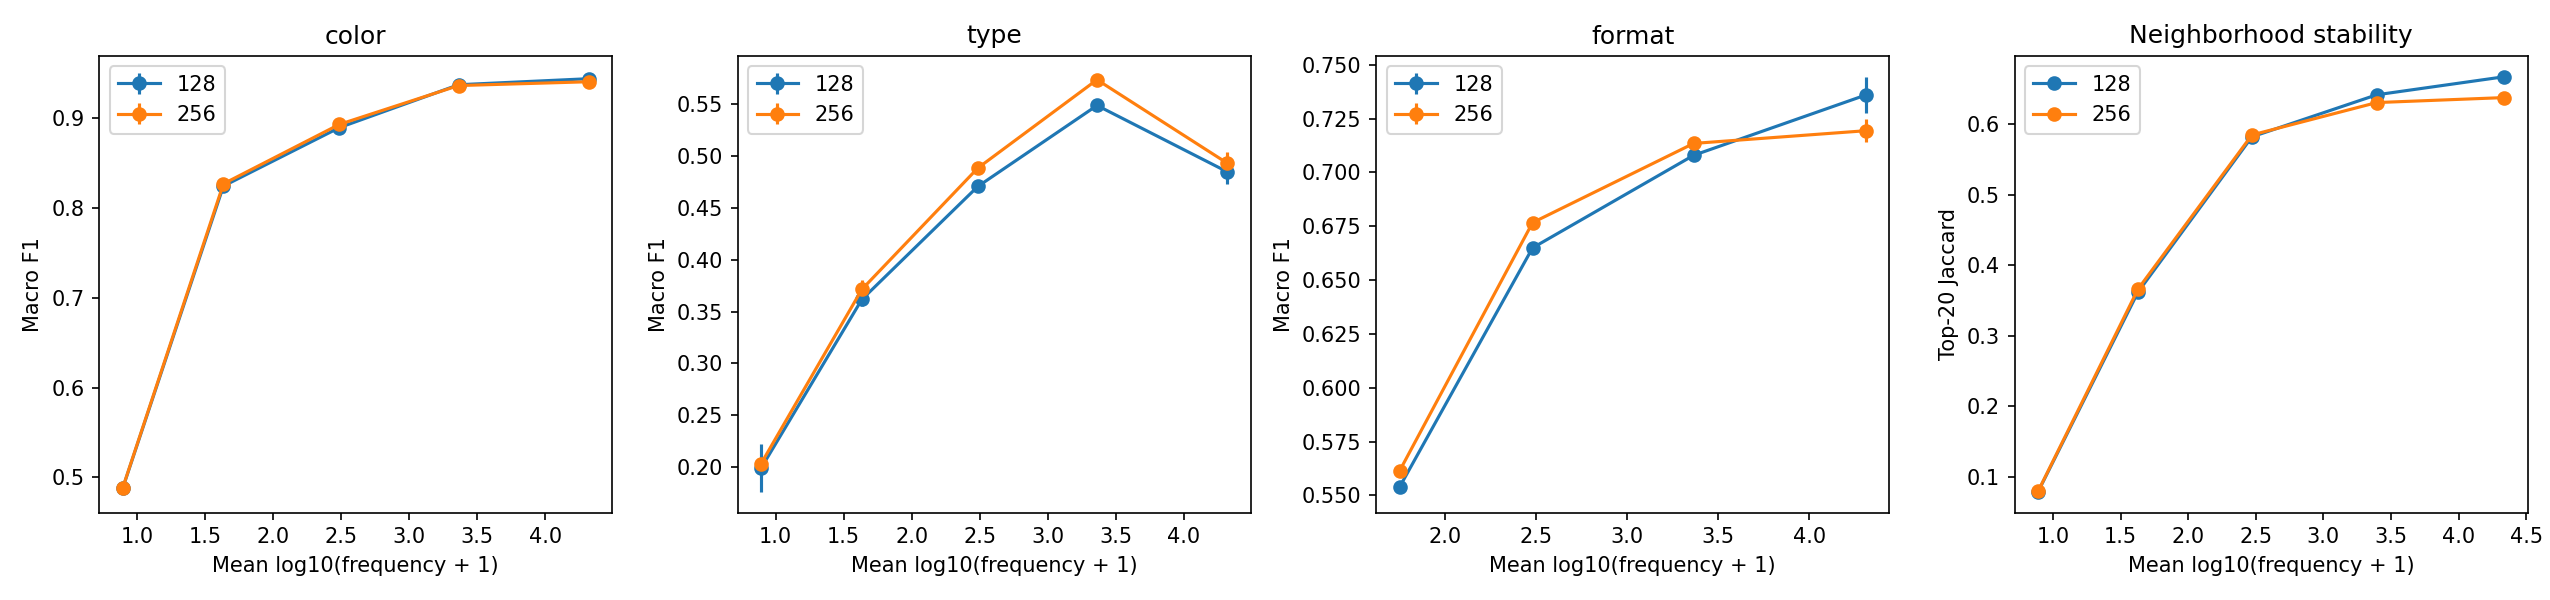

In [10]:
show(read_result('stability_by_frequency.csv'))
show(read_result('frequency_reliability_screen.csv'))
show(read_result('retrieval_frequency_by_seed.csv').groupby(['dimension','kind','frequency_bucket']).agg(mrr=('mrr','mean'),mrr_sd=('mrr','std'),pairs=('pairs','mean')).reset_index(),limit=35)
display(Image(filename=str(EXPERIMENT_ROOT/'frequency_quality.png')))


## 10. Source overlap and disjoint associations

First quantify exact shared contexts. The revised comparison removes every shared context from all
source groups before computing source-specific associations. This removes exact duplicates, not shared
metagames or selection bias. It is not source-held-out training and is not a headline dimension metric.
Unknown-source contexts stay in training.


In [11]:
show(read_result('source_overlap.csv'))
for mode in ['overlapping','disjoint']:
    path=EXPERIMENT_ROOT/f'source_associations_{mode}.csv'
    if path.exists():
        display(Markdown(f'**{mode} contexts**'))
        show(pd.read_csv(path).groupby(['source_a','source_b']).agg(mean_jaccard=('jaccard','mean'),anchors=('anchor','size'),shared_contexts=('overlapping_contexts','max')).reset_index())
    else:
        display(Markdown(f'{mode}: insufficient supported source/anchor observations; independence is not established.'))


,source_a,source_b,contexts_a,contexts_b,shared,jaccard
0,moxfield,mtgtop8,453050,111957,3413,0.006077
1,moxfield,deckbox,453050,123973,3209,0.005592
2,mtgtop8,deckbox,111957,123973,2100,0.008981


**overlapping contexts**

,source_a,source_b,mean_jaccard,anchors,shared_contexts
0,moxfield,deckbox,0.406833,7,3209
1,moxfield,mtgtop8,0.426084,7,3413
2,mtgtop8,deckbox,0.352980,7,2100


**disjoint contexts**

,source_a,source_b,mean_jaccard,anchors,shared_contexts
0,moxfield,deckbox,0.406833,7,0
1,moxfield,mtgtop8,0.430291,7,0
2,mtgtop8,deckbox,0.337217,7,0


## 11. Dimension decision with uncertainty and cost

Average card-split repeats within each training seed, then report mean ± sample standard deviation
across the three training seeds. Paired 95% t intervals use the same training seed across dimensions.
Three seeds give uncertain intervals; multiple metrics are not multiplicity-adjusted.

A preferred dimension requires at least two primary semantic/retrieval metrics with paired intervals
wholly beyond the prespecified practical margin (0.01 F1/MRR; 0.05 MAE), with no primary metric clearly
favoring the other. Otherwise: **no meaningful difference yet**. This is a conservative research rule,
not an equivalence proof. Cost and rare-card behavior remain part of the decision.


In [12]:
show(read_result('dimension_comparison.csv'),limit=50)
show(read_result('individual_seed_metrics.csv').query("metric in ['color_macro_f1','type_macro_f1','mana_mae','format_macro_f1','archetype_macro_f1','neighborhood_jaccard']"),limit=40)
show(read_result('paired_dimension_differences.csv'),limit=50)
display(Markdown((EXPERIMENT_ROOT/'report.md').read_text(encoding='utf-8')))


,metric,128,256
0,archetype_macro_f1,0.8690 ± 0.0115,0.8646 ± 0.0080
1,centroid_recall10,0.1890 ± 0.0053,0.1285 ± 0.0060
2,centroid_recall25,0.2701 ± 0.0155,0.2103 ± 0.0007
3,centroid_recall50,0.3568 ± 0.0117,0.2710 ± 0.0239
4,centroid_rr,0.0757 ± 0.0100,0.0587 ± 0.0050
5,color_macro_f1,0.8708 ± 0.0007,0.8729 ± 0.0005
6,corpus_supported_recall10,0.4400 ± 0.0200,0.4400 ± 0.0173
7,corpus_supported_recall25,0.6333 ± 0.0058,0.6000 ± 0.0100
8,corpus_supported_recall50,0.6967 ± 0.0058,0.6933 ± 0.0153
9,corpus_supported_rr,0.2082 ± 0.0020,0.2044 ± 0.0039


,dimension,seed,metric,value
0,128,42,archetype_macro_f1,0.865389
1,128,42,color_macro_f1,0.869961
2,128,42,format_macro_f1,0.687364
3,128,42,mana_mae,1.108976
12,128,42,type_macro_f1,0.474295
13,128,43,archetype_macro_f1,0.859645
14,128,43,color_macro_f1,0.870978
15,128,43,format_macro_f1,0.688192
16,128,43,mana_mae,1.107891
25,128,43,type_macro_f1,0.473655


,metric,delta_256_minus_128,delta_sd,ci95_low,ci95_high,practical_margin,assessment
0,archetype_macro_f1,-0.004336,0.008013,-0.024241,0.015570,0.01,statistically_unresolved
1,centroid_recall10,-0.060571,0.011360,-0.088791,-0.032351,0.01,clear_practical_difference
2,centroid_recall25,-0.059877,0.015056,-0.097277,-0.022476,0.01,clear_practical_difference
3,centroid_recall50,-0.085760,0.012183,-0.116024,-0.055497,0.01,clear_practical_difference
4,centroid_rr,-0.016965,0.005972,-0.031801,-0.002130,0.01,weak_trend
5,color_macro_f1,0.002092,0.001045,-0.000505,0.004688,0.01,statistically_unresolved
6,corpus_supported_recall10,0.000000,0.010000,-0.024841,0.024841,0.01,statistically_unresolved
7,corpus_supported_recall25,-0.033333,0.011547,-0.062018,-0.004649,0.01,weak_trend
8,corpus_supported_recall50,-0.003333,0.015275,-0.041279,0.034612,0.01,statistically_unresolved
9,corpus_supported_rr,-0.003785,0.003522,-0.012535,0.004966,0.01,statistically_unresolved


# Second Card2Vec experiment

**Decision: no meaningful difference yet.**

Three independent training seeds per dimension; three fixed card splits are averaged within each seed. Values are mean ± sample SD across training seeds.

```text
              metric             128             256
  archetype_macro_f1 0.8690 ± 0.0115 0.8646 ± 0.0080
         centroid_rr 0.0757 ± 0.0100 0.0587 ± 0.0050
      color_macro_f1 0.8708 ± 0.0007 0.8729 ± 0.0005
 corpus_supported_rr 0.2082 ± 0.0020 0.2044 ± 0.0039
     format_macro_f1 0.6874 ± 0.0007 0.6955 ± 0.0007
mana_bucket_macro_f1 0.3252 ± 0.0006 0.3292 ± 0.0019
            mana_mae 1.1093 ± 0.0016 1.1003 ± 0.0009
 mechanical_combo_rr 0.0337 ± 0.0031 0.0435 ± 0.0038
neighborhood_jaccard 0.4723 ± 0.0017 0.4653 ± 0.0009
       type_macro_f1 0.4752 ± 0.0022 0.4899 ± 0.0017
```

**Clear practical differences:** type_macro_f1 (256 has the better point estimate).

**Weak trends:** centroid_rr (128 has the better point estimate); format_macro_f1 (256 has the better point estimate); mana_bucket_macro_f1 (256 has the better point estimate); mana_mae (256 has the better point estimate).

**Unresolved differences:** archetype_macro_f1 (128 has the better point estimate); color_macro_f1 (256 has the better point estimate); corpus_supported_rr (128 has the better point estimate); mechanical_combo_rr (256 has the better point estimate).

**Supplementary retrieval trade-off:** held-out centroid Recall@50 is 35.7% at 128 versus 27.1% at 256. Its paired interval is in the differences table. These correlated retrieval metrics are not counted as independent votes in the overall decision. "No meaningful difference yet" means no consistent overall capacity winner, not that every metric is equal.

**Long tail:** descriptive macro F1 by logarithmic frequency bucket:

```text
 dimension   task               group    value
       128  color      frequency:rare 0.824069
       128  color frequency:very_rare 0.488041
       128 format      frequency:rare 0.553903
       128   type      frequency:rare 0.361644
       128   type frequency:very_rare 0.199301
       256  color      frequency:rare 0.826572
       256  color frequency:very_rare 0.488466
       256 format      frequency:rare 0.561385
       256   type      frequency:rare 0.371343
       256   type frequency:very_rare 0.203643
```

**Cost:** input vectors use 16.42 MiB at 128 versus 32.83 MiB at 256. Mean training time was 15.9 versus 18.3 minutes. The 256-dimensional downstream input tensor is twice as large. Timings reflect concurrent jobs and are approximate.

**Stability and certainty:** top-20 Jaccard is shown above and by frequency in stability_by_frequency.csv. Those comparisons share models; no independence-based interval is assigned to them. Paired 95% t intervals for primary scores are in paired_dimension_differences.csv; three seeds and multiple comparisons limit certainty.

**Retrieval limitation:** several mechanical pairs with at least 1,000 observed shared contexts still rank outside the top 50. The problem is not simply absent training data. See all_retrieval.csv for support, PMI, ranks and percentiles.

**Direct co-occurrence check:** mechanical-combo incidence MRR is 0.384, versus SGNS cosine MRR 0.034–0.044. If incidence is stronger, these failures concern the learned representation/scoring, not an intrinsic absence of co-occurrence evidence.

**Scope:** mana uses finite [0,20] values with explicit exclusions; the original contaminated regression is not a comparator. Expanded archetypes remain curated, and some split-level categories have only two positives. Disjoint source agreement is not source-held-out generalization. Rare/new cards and rules-dependent relationships remain weaknesses of pure co-occurrence training.

Details: methodology_and_diagnostics.md, individual_seed_metrics.csv, baseline_comparison.csv, and frequency_quality.png. Only finite applicable metrics are reported; unavailable statistics have explicit reasons.

## Notes for the next experiment

Keep first-run artifacts immutable. Audit target ranges and joins before fitting; never interpret
all-NaN tables as results. Inspect context titles together with structure, and retain unknown provenance.
Use independent seed/epoch random streams and report training-seed uncertainty separately from card splits.
Do not promote tiny archetype tests or overlapping-source agreement to broad generalization claims.

New cards, extremely rare cards, obscure mechanical combos and rules-text relationships remain weaknesses
of pure co-occurrence embeddings. They motivate future work but no downstream or text-model architecture
is added in this notebook.


# Static v3 — geometry, compression and compatibility

This is an isolated investigation. The v2 notebook cells and saved results above remain historical;
v3 reads frozen v2 inputs and writes only `artifacts/card2vec/static_v3/`.
Training/matrix/probe computation is never triggered by Run All in this section.
See `docs/card2vec-static-v3.md` for explicit stage commands.

## V3.1 Experiment configuration

128/256 dimensions; seeds 42/43/44; the same frozen vocabulary, cleaned contexts,
metadata targets and card splits as v2. Full-incidence weighting differs from SGNS's
32 sampled pairs/context; comparisons cannot isolate objective effects by themselves.


In [13]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Markdown, Image
V3_ROOT = Path.cwd() if (Path.cwd() / 'src/mtgdeck').exists() else Path.cwd().parent
sys.path.insert(0, str(V3_ROOT / 'src'))
from mtgdeck import static_geometry as geometry
V3_OUTPUT = globals().get('V3_OUTPUT_OVERRIDE', V3_ROOT / 'artifacts/card2vec/static_v3')
ALLOW_V3_EXPENSIVE = False  # CLI also requires --allow-expensive; review never invokes it.
def v3_table(relative, limit=30):
    path = V3_OUTPUT / relative
    if path.exists() and path.stat().st_size > 2:
        frame = pd.read_csv(path, keep_default_na=False)
        display(frame.head(limit))
    else:
        print(f'Not run / unavailable: {relative}')
def v3_json(relative):
    path = V3_OUTPUT / relative
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    print(f'Not run: {relative}')
    return None
print('Saved-output review only:', V3_OUTPUT)
display(geometry.POLICY)


Saved-output review only: c:\Users\Kevin\Documents\GitHub\mtg-deck-evaluator\artifacts\card2vec\static_v3


{'version': 'static_v3',
 'dimensions': [128, 256],
 'seeds': [42, 43, 44],
 'split_seeds': [101, 102, 103],
 'row_block': 128,
 'counts': 'C_ij = number of frozen contexts containing both i and j; symmetric; diagonal zero; quantities ignored',
 'context_weight': 'one per containing context for each pair; large contexts contribute more total pairs than small contexts',
 'sgns_weight_difference': 'SGNS samples 32 pairs per context; full incidence does not match its per-pair exposure weighting. Objective effects cannot be isolated causally.',
 'normalized_incidence': 'C_ij / sqrt(f_i f_j), same formula as v2 incidence baseline',
 'pmi': 'log2(C_ij * N / (f_i f_j)); binary-context marginals, no smoothing; absent pairs score -inf',
 'ppmi': 'max(PMI, 0); absent pairs and diagonal zero',
 'ties': 'pessimistic rank: all non-self candidates with score >= partner score; -inf absent PMI pairs rank last',
 'svd': {'algorithm': 'streamed randomized SVD of sparse PPMI; QR-normalized power iteratio

## V3.2 Load frozen static_v2 artifacts

All six `model.gensim` files retain `wv.vectors` and `syn1neg`. The audit aligns both
matrices by vocabulary name and checks input vectors exactly against `vectors.npy`.
These are the old frozen models, not newly retrained approximations.


In [14]:
inventory = v3_json('model_inventory.json')
if inventory: display(pd.DataFrame(inventory))


,seed,dimension,path,origin,context_vectors,retraining_required,vocabulary
0,42,128,seed_42\128\sample_0,frozen_static_v2,True,False,33623
1,42,256,seed_42\256\sample_0,frozen_static_v2,True,False,33623
2,43,128,seed_43\128\sample_0,frozen_static_v2,True,False,33623
3,43,256,seed_43\256\sample_0,frozen_static_v2,True,False,33623
4,44,128,seed_44\128\sample_0,frozen_static_v2,True,False,33623
5,44,256,seed_44\256\sample_0,frozen_static_v2,True,False,33623


## V3.3 Verify corpus/model provenance

The v3 audit hashes packed tokens, offsets, frequencies, vocabulary, model files,
exclusion manifests and the frozen evaluation cache. Every compute stage revalidates
these hashes. No live scraper data or newer metadata is substituted.
The packed artifact has 1,002,915 contexts and 33,623 cards; source/audit counts may differ.


In [15]:
provenance = v3_json('provenance.json')
if provenance:
    display({k: provenance[k] for k in ('training_contexts', 'vocabulary', 'evaluation_policy', 'packages')})


{'training_contexts': 1002915,
 'vocabulary': 33623,
 'evaluation_policy': {'mana_domain': [0, 20],
  'mana_bins': '[0,1), [1,2), [2,3), [3,4), [4,5), [5,6), [6,inf)',
  'split_seeds': [101, 102, 103],
  'training_seeds': [42, 43, 44],
  'dimensions': [128, 256],
  'concepts_sha256': '266b9602e85c1bf80cf9d664c7ffb9d2887a0dad21dc625dbb72d412b02ff001',
  'metadata_sha256': 'fc661541f554194fa7c0687ff02ce69cbf22e71ca089fe9c2cae8570bd1203aa',
  'module_sha256': '50e41d62696203ecde94e00da420d1352c5296e85891d34a09ec5a52db33b3b2',
  'statistical_pairs': 'top five incidence-cosine partners per fixed anchor with joint count >=100 and lift >=2; transductive',
  'random_baseline': 'seeded 256-dimensional draws truncated to each model dimension; same card splits',
  'frequency_buckets': {'very_rare': '<10',
   'rare': '10-99',
   'medium': '100-999',
   'common': '1000-9999',
   'very_common': '>=10000'}},
 'packages': {'numpy': '2.4.3',
  'scipy': '1.17.1',
  'pandas': '3.0.1',
  'scikit-learn': '

## V3.4 SGNS input/context geometry

Compare input-input cosine, context-context cosine, input-context dot/cosine,
symmetric cross dot/cosine, and cosine of `u+v`. Directional scores are reported
in both directions. Similarity is not the SGNS training score; cross dot exposes
the learned input/output association. Cross scores do not get misleading single-vector probes.


In [16]:
v3_table('aggregate_metrics.csv')


,method,dimension,task,metric,mean,replicates,replicate_kind,sd,sd_status
0,combined_cosine,128,complementary_mechanical,recall10,0.777778,3,training_seed,0.096225,available
1,combined_cosine,128,complementary_mechanical,recall20,0.833333,3,training_seed,0.000000,available
2,combined_cosine,128,complementary_mechanical,recall50,1.000000,3,training_seed,0.000000,available
3,combined_cosine,128,complementary_mechanical,rr,0.440169,3,training_seed,0.027506,available
4,combined_cosine,128,corpus_supported,recall10,0.486667,3,training_seed,0.005774,available
5,combined_cosine,128,corpus_supported,recall20,0.623333,3,training_seed,0.005774,available
6,combined_cosine,128,corpus_supported,recall50,0.723333,3,training_seed,0.011547,available
7,combined_cosine,128,corpus_supported,rr,0.217818,3,training_seed,0.000855,available
8,combined_cosine,128,heldout_centroid,recall10,0.210905,3,training_seed,0.016999,available
9,combined_cosine,128,heldout_centroid,recall20,0.300412,3,training_seed,0.015838,available


## V3.5 Incidence / PMI / PPMI

Binary context incidence gives symmetric joint counts, a zero diagonal, and no
quantity weighting. Normalized incidence is `C_ij/sqrt(f_i*f_j)` as in v2.
PMI is `log2(C_ij*N/(f_i*f_j))` with no smoothing; absent pairs score negative infinity.
PPMI clips negative PMI to zero. Ties use pessimistic rank, excluding self.
Counts and PPMI are cached as sparse 128-row shards; no dense V×V allocation.


In [17]:
matrix_index = v3_json('matrices/index.json')
if matrix_index: display({k:v for k,v in matrix_index.items() if k != 'shards'})


Not run: matrices/index.json


## V3.6 Truncated-SVD representations

Randomized SVD streams the PPMI shards with 10 oversamples and three QR-normalized
power iterations, at ranks 128/256 and seeds 42/43/44. Embeddings are `U sqrt(S)`.
These seeds measure factorization variability on one matrix. Both cosine and dot
retrieval are evaluated. A Gram matrix is not the exact reconstruction of indefinite PPMI.


In [18]:
display(geometry.POLICY['svd'])


{'algorithm': 'streamed randomized SVD of sparse PPMI; QR-normalized power iteration',
 'oversamples': 10,
 'power_iterations': 3,
 'embedding': 'U sqrt(S)',
 'replicates': 'randomized factorization seeds on one fixed matrix, not independent corpora'}

## V3.7 Semantic versus complementary benchmarks

Three inspectable same-role pairs are separate from the five requested complementary
pairs. The unchanged five-pair v2 benchmark is a third category. Coverage includes
missing vocabulary and metadata, and both directions never count as independent pairs.
Corpus-supported partners reuse the frozen v2 list and are explicitly transductive.


In [19]:
v3_table('coverage_summary.csv')
v3_table('semantic_pairs.csv', 12)
v3_table('mechanical_pairs.csv', 20)


,kind,status,directed_queries,unique_pairs
0,complementary_mechanical,covered,6,3
1,complementary_mechanical,missing_or_ambiguous_metadata,4,2
2,corpus_supported,covered,100,100
3,mechanical_v2,covered,10,5
4,semantic_similarity,covered,2,1
5,semantic_similarity,missing_or_ambiguous_metadata,4,2


,kind,pair_id,anchor,partner,reason,status,...,recall10,recall20,recall50,method,dimension,seed
0,semantic_similarity,semantic_similarity:1,third path iconoclast,young pyromancer,noncreature-spell token engines,covered,...,0.0,0.0,1.0,combined_cosine,128,42
1,semantic_similarity,semantic_similarity:1,young pyromancer,third path iconoclast,noncreature-spell token engines,covered,...,1.0,1.0,1.0,combined_cosine,128,42
2,semantic_similarity,semantic_similarity:1,third path iconoclast,young pyromancer,noncreature-spell token engines,covered,...,0.0,0.0,0.0,combined_cosine,128,43
3,semantic_similarity,semantic_similarity:1,young pyromancer,third path iconoclast,noncreature-spell token engines,covered,...,1.0,1.0,1.0,combined_cosine,128,43
4,semantic_similarity,semantic_similarity:1,third path iconoclast,young pyromancer,noncreature-spell token engines,covered,...,0.0,0.0,1.0,combined_cosine,128,44
5,semantic_similarity,semantic_similarity:1,young pyromancer,third path iconoclast,noncreature-spell token engines,covered,...,1.0,1.0,1.0,combined_cosine,128,44
6,semantic_similarity,semantic_similarity:1,third path iconoclast,young pyromancer,noncreature-spell token engines,covered,...,0.0,0.0,1.0,combined_cosine,256,42
7,semantic_similarity,semantic_similarity:1,young pyromancer,third path iconoclast,noncreature-spell token engines,covered,...,1.0,1.0,1.0,combined_cosine,256,42
8,semantic_similarity,semantic_similarity:1,third path iconoclast,young pyromancer,noncreature-spell token engines,covered,...,0.0,0.0,0.0,combined_cosine,256,43
9,semantic_similarity,semantic_similarity:1,young pyromancer,third path iconoclast,noncreature-spell token engines,covered,...,1.0,1.0,1.0,combined_cosine,256,43


,kind,pair_id,anchor,partner,reason,status,...,recall10,recall20,recall50,method,dimension,seed
0,mechanical_v2,mechanical_v2:2,curiosity,"niv-mizzet, parun",unchanged historical benchmark,covered,...,0.0,0.0,0.0,combined_cosine,128,42
1,complementary_mechanical,complementary_mechanical:4,dark depths,thespian's stage,explicit mechanical relationship,covered,...,1.0,1.0,1.0,combined_cosine,128,42
2,complementary_mechanical,complementary_mechanical:0,demonic consultation,thassa's oracle,explicit mechanical relationship,covered,...,0.0,0.0,1.0,combined_cosine,128,42
3,mechanical_v2,mechanical_v2:0,demonic consultation,thassa's oracle,unchanged historical benchmark,covered,...,0.0,0.0,1.0,combined_cosine,128,42
4,complementary_mechanical,complementary_mechanical:2,guilty conscience,stuffy doll,explicit mechanical relationship,covered,...,1.0,1.0,1.0,combined_cosine,128,42
5,mechanical_v2,mechanical_v2:4,guilty conscience,stuffy doll,unchanged historical benchmark,covered,...,1.0,1.0,1.0,combined_cosine,128,42
6,mechanical_v2,mechanical_v2:2,"niv-mizzet, parun",curiosity,unchanged historical benchmark,covered,...,0.0,0.0,0.0,combined_cosine,128,42
7,mechanical_v2,mechanical_v2:3,"niv-mizzet, parun",ophidian eye,unchanged historical benchmark,covered,...,0.0,0.0,0.0,combined_cosine,128,42
8,mechanical_v2,mechanical_v2:3,ophidian eye,"niv-mizzet, parun",unchanged historical benchmark,covered,...,0.0,0.0,0.0,combined_cosine,128,42
9,complementary_mechanical,complementary_mechanical:2,stuffy doll,guilty conscience,explicit mechanical relationship,covered,...,1.0,1.0,1.0,combined_cosine,128,42


## V3.8 Diagnostic compatibility scorer

A regularized diagonal bilinear score on frozen, unit-normalized input vectors has
only d weights. It fits corpus-association labels, not the five combo pairs.
All benchmark endpoints are excluded from scorer training and pair validation.
A fixed unordered-pair hash separates train/validation; positives require joint>=100
and lift>=2, negatives have zero co-occurrence. Unobserved pairs are not proven non-synergies.
Fewer than 100 examples/class/split makes the diagnostic unavailable. Even adequate
supervision does not make the tiny mechanical evaluation statistically conclusive.


In [20]:
display(geometry.POLICY['compatibility'])
for path in sorted((V3_OUTPUT / 'compatibility').glob('*/fit.json')):
    display({'model': path.parent.name, **json.loads(path.read_text())})


{'model': 'symmetric diagonal bilinear e_i^T diag(w) e_j with intercept',
 'labels': 'balanced sampled pairs: positives C>=100 and lift>=2; negatives C=0; ambiguous pairs excluded',
 'holdout': 'all covered benchmark endpoints excluded from scorer fitting and pair validation; separate pair-hash holdout inside remaining population',
 'max_pairs': 20000,
 'proposal_budget': 2000000,
 'seed': 202,
 'regularization_C': 0.1,
 'scope': 'transductive corpus-association diagnostic, not ground-truth mechanical synergy'}

## V3.9 Linear probes

The v2 frozen probes, metadata and three card splits are reused for input, context,
combined and PPMI-SVD representations. Color/type/format/archetype macro F1 and clean
mana MAE are reported. Each probes.csv retains per-label support, baseline comparisons,
and frequency groups. Single-card probes and cosine-centroid evaluation are not
applicable to a pure pair scorer. Card splits are averaged within each model.


In [21]:
missing = v3_json('unavailable_metrics.json')
if missing: display(pd.DataFrame(missing).head(20).fillna('not_applicable'))


,method,dimension,seed,task,reason
0,combined_cosine,128,42,linear_probes,not run in retrieval-only stage; run probes stage
1,combined_cosine,128,43,linear_probes,not run in retrieval-only stage; run probes stage
2,combined_cosine,128,44,linear_probes,not run in retrieval-only stage; run probes stage
3,combined_cosine,256,42,linear_probes,not run in retrieval-only stage; run probes stage
4,combined_cosine,256,43,linear_probes,not run in retrieval-only stage; run probes stage
5,combined_cosine,256,44,linear_probes,not run in retrieval-only stage; run probes stage
6,context_cosine,128,42,linear_probes,not run in retrieval-only stage; run probes stage
7,context_cosine,128,43,linear_probes,not run in retrieval-only stage; run probes stage
8,context_cosine,128,44,linear_probes,not run in retrieval-only stage; run probes stage
9,context_cosine,256,42,linear_probes,not run in retrieval-only stage; run probes stage


## V3.10 Frequency / rare-card stability

Use the same fixed frequency-stratified anchors for all methods. Compare top-20
neighbor Jaccard across seeds, including cross scoring and combined embeddings.
Seed-pair observations share trained models and are descriptive, not independent runs.
Deterministic incidence has no training-seed stability. Tied scores may inflate snapshot
agreement; zero rows should not be interpreted as learned robust neighborhoods.


,method,dimension,bucket,mean_jaccard,anchors,anchor_seed_pair_observations
0,combined_cosine,128,common,0.696492,53,159
1,combined_cosine,128,medium,0.626998,51,153
2,combined_cosine,128,rare,0.405422,50,150
3,combined_cosine,128,very_common,0.752837,54,162
4,combined_cosine,128,very_rare,0.098214,50,150
...,...,...,...,...,...,...
55,symmetric_cross_cosine,256,common,0.636959,53,159
56,symmetric_cross_cosine,256,medium,0.609074,51,153
57,symmetric_cross_cosine,256,rare,0.486537,50,150
58,symmetric_cross_cosine,256,very_common,0.581346,54,162


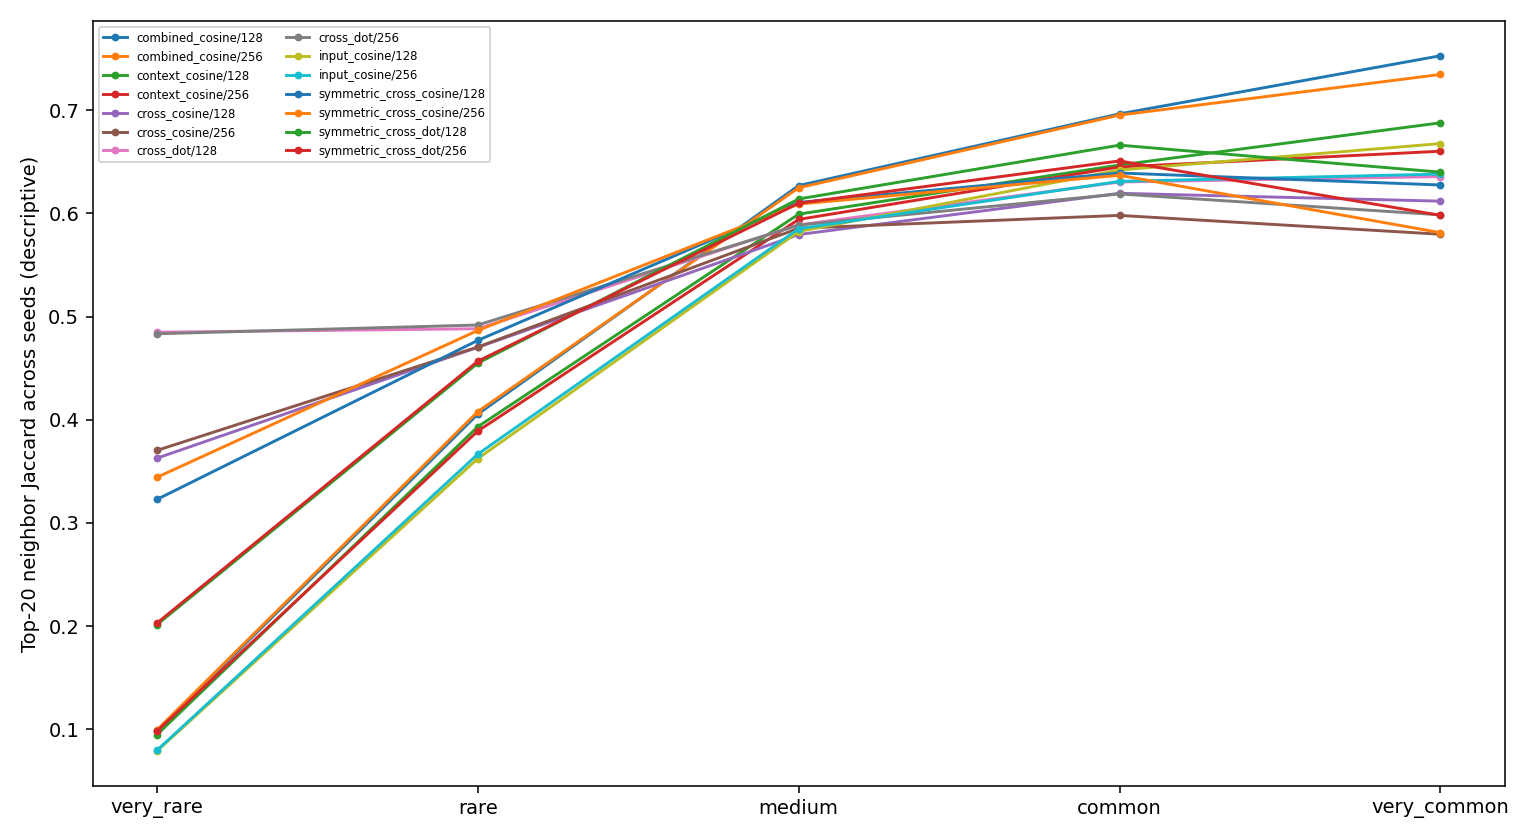

In [22]:
v3_table('stability_by_frequency.csv', 60)
if (V3_OUTPUT / 'frequency_stability.png').exists(): display(Image(filename=str(V3_OUTPUT / 'frequency_stability.png')))


## V3.11 Aggregate tables and plots

Report means and sample SD across three model seeds; deterministic scores have no SD.
Paired 128/256 differences use matched seeds. SVD seed variability has a different
interpretation from SGNS training variability. Recall@10/20/50 are correlated outcomes;
small unadjusted intervals on tiny curated benchmarks do not establish a general winner.


,method,dimension,task,metric,mean,replicates,replicate_kind,sd,sd_status
0,combined_cosine,128,complementary_mechanical,recall10,0.777778,3,training_seed,0.096225,available
1,combined_cosine,128,complementary_mechanical,recall20,0.833333,3,training_seed,0.000000,available
2,combined_cosine,128,complementary_mechanical,recall50,1.000000,3,training_seed,0.000000,available
3,combined_cosine,128,complementary_mechanical,rr,0.440169,3,training_seed,0.027506,available
4,combined_cosine,128,corpus_supported,recall10,0.486667,3,training_seed,0.005774,available
...,...,...,...,...,...,...,...,...,...
55,context_cosine,128,mechanical_v2,rr,0.030710,3,training_seed,0.005331,available
56,context_cosine,128,semantic_similarity,recall10,0.500000,3,training_seed,0.000000,available
57,context_cosine,128,semantic_similarity,recall20,0.500000,3,training_seed,0.000000,available
58,context_cosine,128,semantic_similarity,recall50,0.500000,3,training_seed,0.000000,available


,method,task,metric,pairs,status,delta_256_minus_128,sd,ci95_low,ci95_high
0,combined_cosine,complementary_mechanical,recall10,3,descriptive_unadjusted_interval,0.000000,0.000000,0.000000,0.000000
1,combined_cosine,complementary_mechanical,recall20,3,descriptive_unadjusted_interval,0.000000,0.000000,0.000000,0.000000
2,combined_cosine,complementary_mechanical,recall50,3,descriptive_unadjusted_interval,0.000000,0.000000,0.000000,0.000000
3,combined_cosine,complementary_mechanical,rr,3,descriptive_unadjusted_interval,0.010787,0.017808,-0.033451,0.055025
4,combined_cosine,corpus_supported,recall10,3,descriptive_unadjusted_interval,-0.006667,0.015275,-0.044612,0.031279
5,combined_cosine,corpus_supported,recall20,3,descriptive_unadjusted_interval,-0.003333,0.005774,-0.017676,0.011009
6,combined_cosine,corpus_supported,recall50,3,descriptive_unadjusted_interval,0.016667,0.005774,0.002324,0.031009
7,combined_cosine,corpus_supported,rr,3,descriptive_unadjusted_interval,0.002303,0.004440,-0.008727,0.013332
8,combined_cosine,heldout_centroid,recall10,3,descriptive_unadjusted_interval,-0.021605,0.003086,-0.029272,-0.013938
9,combined_cosine,heldout_centroid,recall20,3,descriptive_unadjusted_interval,-0.017490,0.001782,-0.021916,-0.013063


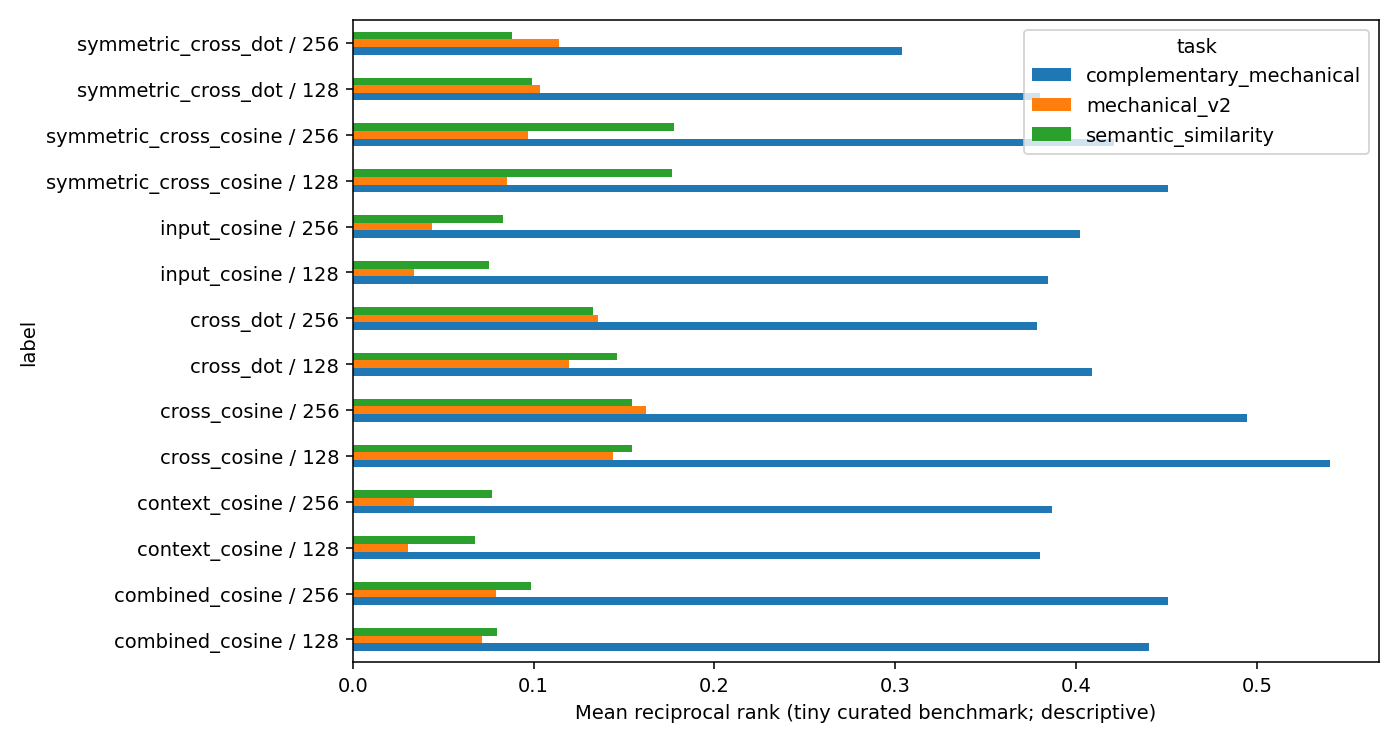

In [23]:
v3_table('aggregate_metrics.csv', 60)
v3_table('paired_dimension_differences.csv', 30)
if (V3_OUTPUT / 'retrieval_mrr.png').exists(): display(Image(filename=str(V3_OUTPUT / 'retrieval_mrr.png')))


## V3.12 Interpretation

Distinguish **semantic representation**, **static similarity retrieval**, **pairwise
compatibility**, and **format-specific downstream recommendation**. Good probes do
not imply good combo retrieval. Poor input cosine does not make the embedding useless.
Card2Vec can be a semantic/statistical prior for a later format-specific model without
placing every complementary combo nearby. This experiment does not test that downstream architecture.

Read the completion status before interpreting comparisons: pending experiments are
not negative findings. Do not attribute supported combo failures automatically to sparse data.

### Completed SGNS diagnostics (partial v3 run)

All 42 frozen-model scorer evaluations completed; matrix baselines, SVD,
compatibility fitting and linear probes are still pending.

On the **unchanged v2 mechanical benchmark**, input cosine MRR is 0.0337/0.0435
for 128/256 dimensions, versus 0.1195/0.1353 for input-context dot scoring.
Combined-vector cosine gives 0.0715/0.0791. These results show that the scoring
choice exposes different association information in the same frozen models.

On the **requested complementary set**, input cosine MRR is instead 0.3843/0.4024.
The semantic set gives 0.0755/0.0828. These tiny, different pair sets do not support
a blanket claim that cosine is better at semantic than complementary retrieval.
Inspect individual ranks and avoid mixing the new benchmark with the historical one.

Very-rare-card top-20 Jaccard is 0.0788/0.0795 for input cosine,
0.4848/0.4833 for input-context dot, and 0.0982/0.0992 for combined cosine.
Greater reproducibility is not evidence of useful rare-card recommendations:
vector norms, popularity, or shared generic neighbors may contribute.
No claim about PPMI-SVD or learned compatibility is available yet.


In [24]:
summary = v3_json('summary.json')
if summary:
    display({k: summary[k] for k in ('status', 'completed_scorers', 'pending_scorers', 'pending_probes', 'retraining')})


{'status': 'partial',
 'completed_scorers': 42,
 'pending_scorers': ['compatibility_diagonal:128:42',
  'compatibility_diagonal:128:43',
  'compatibility_diagonal:128:44',
  'compatibility_diagonal:256:42',
  'compatibility_diagonal:256:43',
  'compatibility_diagonal:256:44',
  'incidence_cosine:0:deterministic',
  'pmi:0:deterministic',
  'ppmi:0:deterministic',
  'ppmi_svd_cosine:128:42',
  'ppmi_svd_cosine:128:43',
  'ppmi_svd_cosine:128:44',
  'ppmi_svd_cosine:256:42',
  'ppmi_svd_cosine:256:43',
  'ppmi_svd_cosine:256:44',
  'ppmi_svd_dot:128:42',
  'ppmi_svd_dot:128:43',
  'ppmi_svd_dot:128:44',
  'ppmi_svd_dot:256:42',
  'ppmi_svd_dot:256:43',
  'ppmi_svd_dot:256:44',
  'raw_incidence:0:deterministic'],
 'pending_probes': ['input_cosine_d128_s42',
  'input_cosine_d128_s43',
  'input_cosine_d128_s44',
  'input_cosine_d256_s42',
  'input_cosine_d256_s43',
  'input_cosine_d256_s44',
  'context_cosine_d128_s42',
  'context_cosine_d128_s43',
  'context_cosine_d128_s44',
  'context_co

## V3.13 Saved static_v3 report and executed archive

Run `python scripts/run_static_geometry.py --stage report` after selected stages.
Run `--stage render` to execute only these tagged review cells and create
`artifacts/card2vec/static_v3/notebook_executed.ipynb`. Neither command executes
training, matrix construction or probes. Existing executed archives are not overwritten.


In [25]:
report_path = V3_OUTPUT / 'report.md'
if report_path.exists(): display(Markdown(report_path.read_text(encoding='utf-8')))
else: print('No v3 report yet; run the audit and report stages.')


# Static v3: SGNS geometry, compression and compatibility

Status: **partial**. 42 scorer runs complete; 22 pending; 24 representation probe runs pending; 0 scorers unavailable with recorded reasons.

## Provenance and scope

All training contexts, exclusions, metadata targets and historical models are read from frozen static_v2. Exact hashes are in provenance.json. No historical result is overwritten. model_inventory.json records context-vector availability and whether retraining is necessary.

## Coverage

| kind | status | directed_queries | unique_pairs |
| --- | --- | --- | --- |
| complementary_mechanical | covered | 6 | 3 |
| complementary_mechanical | missing_or_ambiguous_metadata | 4 | 2 |
| corpus_supported | covered | 100 | 100 |
| mechanical_v2 | covered | 10 | 5 |
| semantic_similarity | covered | 2 | 1 |
| semantic_similarity | missing_or_ambiguous_metadata | 4 | 2 |

The three semantic relationships and five requested complementary relationships are tiny curated sets. Both directions are scored, but they are not independent relationships. mechanical_v2 separately preserves the original five pairs (including Tainted Pact and Ophidian Eye). Corpus-supported partners were selected by incidence on this same training corpus; that comparison is transductive and favors incidence by construction.

## Results

| method | dimension | task | metric | mean | replicates | replicate_kind | sd | sd_status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| combined_cosine | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| combined_cosine | 128 | complementary_mechanical | rr | 0.44017 | 3 | training_seed | 0.027506 | available |
| combined_cosine | 128 | corpus_supported | recall50 | 0.72333 | 3 | training_seed | 0.011547 | available |
| combined_cosine | 128 | corpus_supported | rr | 0.21782 | 3 | training_seed | 0.00085512 | available |
| combined_cosine | 128 | heldout_centroid | recall50 | 0.42593 | 3 | training_seed | 0.0030864 | available |
| combined_cosine | 128 | heldout_centroid | rr | 0.089653 | 3 | training_seed | 0.0027097 | available |
| combined_cosine | 128 | mechanical_v2 | recall50 | 0.5 | 3 | training_seed | 0 | available |
| combined_cosine | 128 | mechanical_v2 | rr | 0.071509 | 3 | training_seed | 0.015966 | available |
| combined_cosine | 128 | semantic_similarity | recall50 | 0.83333 | 3 | training_seed | 0.28868 | available |
| combined_cosine | 128 | semantic_similarity | rr | 0.079688 | 3 | training_seed | 0.012106 | available |
| combined_cosine | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| combined_cosine | 256 | complementary_mechanical | rr | 0.45096 | 3 | training_seed | 0.043652 | available |
| combined_cosine | 256 | corpus_supported | recall50 | 0.74 | 3 | training_seed | 0.01 | available |
| combined_cosine | 256 | corpus_supported | rr | 0.22012 | 3 | training_seed | 0.0042111 | available |
| combined_cosine | 256 | heldout_centroid | recall50 | 0.41255 | 3 | training_seed | 0.0047146 | available |
| combined_cosine | 256 | heldout_centroid | rr | 0.088281 | 3 | training_seed | 0.0024567 | available |
| combined_cosine | 256 | mechanical_v2 | recall50 | 0.5 | 3 | training_seed | 0 | available |
| combined_cosine | 256 | mechanical_v2 | rr | 0.079075 | 3 | training_seed | 0.025108 | available |
| combined_cosine | 256 | semantic_similarity | recall50 | 0.83333 | 3 | training_seed | 0.28868 | available |
| combined_cosine | 256 | semantic_similarity | rr | 0.098427 | 3 | training_seed | 0.010423 | available |
| context_cosine | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| context_cosine | 128 | complementary_mechanical | rr | 0.38026 | 3 | training_seed | 0.0088522 | available |
| context_cosine | 128 | corpus_supported | recall50 | 0.69 | 3 | training_seed | 0.01 | available |
| context_cosine | 128 | corpus_supported | rr | 0.20111 | 3 | training_seed | 0.0015689 | available |
| context_cosine | 128 | heldout_centroid | recall50 | 0.29527 | 3 | training_seed | 0.011685 | available |
| context_cosine | 128 | heldout_centroid | rr | 0.068476 | 3 | training_seed | 0.00084167 | available |
| context_cosine | 128 | mechanical_v2 | recall50 | 0.4 | 3 | training_seed | 6.7987e-17 | available |
| context_cosine | 128 | mechanical_v2 | rr | 0.03071 | 3 | training_seed | 0.0053307 | available |
| context_cosine | 128 | semantic_similarity | recall50 | 0.5 | 3 | training_seed | 0 | available |
| context_cosine | 128 | semantic_similarity | rr | 0.067804 | 3 | training_seed | 0.0049569 | available |
| context_cosine | 256 | complementary_mechanical | recall50 | 0.88889 | 3 | training_seed | 0.096225 | available |
| context_cosine | 256 | complementary_mechanical | rr | 0.38666 | 3 | training_seed | 0.0040546 | available |
| context_cosine | 256 | corpus_supported | recall50 | 0.67 | 3 | training_seed | 0 | available |
| context_cosine | 256 | corpus_supported | rr | 0.1936 | 3 | training_seed | 0.0080737 | available |
| context_cosine | 256 | heldout_centroid | recall50 | 0.23354 | 3 | training_seed | 0.0064249 | available |
| context_cosine | 256 | heldout_centroid | rr | 0.055339 | 3 | training_seed | 0.0025357 | available |
| context_cosine | 256 | mechanical_v2 | recall50 | 0.33333 | 3 | training_seed | 0.057735 | available |
| context_cosine | 256 | mechanical_v2 | rr | 0.033793 | 3 | training_seed | 0.0021792 | available |
| context_cosine | 256 | semantic_similarity | recall50 | 0.5 | 3 | training_seed | 0 | available |
| context_cosine | 256 | semantic_similarity | rr | 0.077075 | 3 | training_seed | 0.022691 | available |
| cross_cosine | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_cosine | 128 | complementary_mechanical | rr | 0.54047 | 3 | training_seed | 0.14533 | available |
| cross_cosine | 128 | corpus_supported | recall50 | 0.71667 | 3 | training_seed | 0.0057735 | available |
| cross_cosine | 128 | corpus_supported | rr | 0.18823 | 3 | training_seed | 0.014062 | available |
| cross_cosine | 128 | mechanical_v2 | recall50 | 0.76667 | 3 | training_seed | 0.057735 | available |
| cross_cosine | 128 | mechanical_v2 | rr | 0.14398 | 3 | training_seed | 0.088631 | available |
| cross_cosine | 128 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_cosine | 128 | semantic_similarity | rr | 0.15417 | 3 | training_seed | 0.026021 | available |
| cross_cosine | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_cosine | 256 | complementary_mechanical | rr | 0.49446 | 3 | training_seed | 0.20421 | available |
| cross_cosine | 256 | corpus_supported | recall50 | 0.72 | 3 | training_seed | 0.01 | available |
| cross_cosine | 256 | corpus_supported | rr | 0.18104 | 3 | training_seed | 0.021169 | available |
| cross_cosine | 256 | mechanical_v2 | recall50 | 0.8 | 3 | training_seed | 1.3597e-16 | available |
| cross_cosine | 256 | mechanical_v2 | rr | 0.16205 | 3 | training_seed | 0.091167 | available |
| cross_cosine | 256 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_cosine | 256 | semantic_similarity | rr | 0.15456 | 3 | training_seed | 0.028919 | available |
| cross_dot | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_dot | 128 | complementary_mechanical | rr | 0.40874 | 3 | training_seed | 0.074441 | available |
| cross_dot | 128 | corpus_supported | recall50 | 0.71 | 3 | training_seed | 0.01 | available |
| cross_dot | 128 | corpus_supported | rr | 0.19919 | 3 | training_seed | 0.0021181 | available |
| cross_dot | 128 | mechanical_v2 | recall50 | 0.76667 | 3 | training_seed | 0.057735 | available |
| cross_dot | 128 | mechanical_v2 | rr | 0.11948 | 3 | training_seed | 0.040199 | available |
| cross_dot | 128 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_dot | 128 | semantic_similarity | rr | 0.14611 | 3 | training_seed | 0.017034 | available |
| cross_dot | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_dot | 256 | complementary_mechanical | rr | 0.37821 | 3 | training_seed | 0.16498 | available |
| cross_dot | 256 | corpus_supported | recall50 | 0.71333 | 3 | training_seed | 0.015275 | available |
| cross_dot | 256 | corpus_supported | rr | 0.18513 | 3 | training_seed | 0.025186 | available |
| cross_dot | 256 | mechanical_v2 | recall50 | 0.8 | 3 | training_seed | 0.1 | available |
| cross_dot | 256 | mechanical_v2 | rr | 0.13532 | 3 | training_seed | 0.070932 | available |
| cross_dot | 256 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| cross_dot | 256 | semantic_similarity | rr | 0.13294 | 3 | training_seed | 0.024782 | available |
| input_cosine | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| input_cosine | 128 | complementary_mechanical | rr | 0.38432 | 3 | training_seed | 0.0044325 | available |
| input_cosine | 128 | corpus_supported | recall50 | 0.69667 | 3 | training_seed | 0.0057735 | available |
| input_cosine | 128 | corpus_supported | rr | 0.20821 | 3 | training_seed | 0.0020171 | available |
| input_cosine | 128 | heldout_centroid | recall50 | 0.35082 | 3 | training_seed | 0.011685 | available |
| input_cosine | 128 | heldout_centroid | rr | 0.078685 | 3 | training_seed | 0.003835 | available |
| input_cosine | 128 | mechanical_v2 | recall50 | 0.4 | 3 | training_seed | 6.7987e-17 | available |
| input_cosine | 128 | mechanical_v2 | rr | 0.033698 | 3 | training_seed | 0.003058 | available |
| input_cosine | 128 | semantic_similarity | recall50 | 0.5 | 3 | training_seed | 0 | available |
| input_cosine | 128 | semantic_similarity | rr | 0.075488 | 3 | training_seed | 0.023384 | available |
| input_cosine | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| input_cosine | 256 | complementary_mechanical | rr | 0.40241 | 3 | training_seed | 0.0062402 | available |
| input_cosine | 256 | corpus_supported | recall50 | 0.69333 | 3 | training_seed | 0.015275 | available |
| input_cosine | 256 | corpus_supported | rr | 0.20443 | 3 | training_seed | 0.0038716 | available |
| input_cosine | 256 | heldout_centroid | recall50 | 0.26029 | 3 | training_seed | 0.01285 | available |
| input_cosine | 256 | heldout_centroid | rr | 0.064218 | 3 | training_seed | 0.0020492 | available |
| input_cosine | 256 | mechanical_v2 | recall50 | 0.4 | 3 | training_seed | 6.7987e-17 | available |
| input_cosine | 256 | mechanical_v2 | rr | 0.043516 | 3 | training_seed | 0.0038089 | available |
| input_cosine | 256 | semantic_similarity | recall50 | 0.5 | 3 | training_seed | 0 | available |
| input_cosine | 256 | semantic_similarity | rr | 0.082803 | 3 | training_seed | 0.023026 | available |
| symmetric_cross_cosine | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_cosine | 128 | complementary_mechanical | rr | 0.45054 | 3 | training_seed | 0.025864 | available |
| symmetric_cross_cosine | 128 | corpus_supported | recall50 | 0.74667 | 3 | training_seed | 0.015275 | available |
| symmetric_cross_cosine | 128 | corpus_supported | rr | 0.17631 | 3 | training_seed | 0.0038176 | available |
| symmetric_cross_cosine | 128 | mechanical_v2 | recall50 | 0.76667 | 3 | training_seed | 0.057735 | available |
| symmetric_cross_cosine | 128 | mechanical_v2 | rr | 0.085355 | 3 | training_seed | 0.014638 | available |
| symmetric_cross_cosine | 128 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_cosine | 128 | semantic_similarity | rr | 0.17639 | 3 | training_seed | 0.10868 | available |
| symmetric_cross_cosine | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_cosine | 256 | complementary_mechanical | rr | 0.42101 | 3 | training_seed | 0.09641 | available |
| symmetric_cross_cosine | 256 | corpus_supported | recall50 | 0.75 | 3 | training_seed | 0.017321 | available |
| symmetric_cross_cosine | 256 | corpus_supported | rr | 0.16358 | 3 | training_seed | 0.0086153 | available |
| symmetric_cross_cosine | 256 | mechanical_v2 | recall50 | 0.86667 | 3 | training_seed | 0.057735 | available |
| symmetric_cross_cosine | 256 | mechanical_v2 | rr | 0.09702 | 3 | training_seed | 0.021161 | available |
| symmetric_cross_cosine | 256 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_cosine | 256 | semantic_similarity | rr | 0.17778 | 3 | training_seed | 0.019245 | available |
| symmetric_cross_dot | 128 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_dot | 128 | complementary_mechanical | rr | 0.38007 | 3 | training_seed | 0.092152 | available |
| symmetric_cross_dot | 128 | corpus_supported | recall50 | 0.73667 | 3 | training_seed | 0.015275 | available |
| symmetric_cross_dot | 128 | corpus_supported | rr | 0.19506 | 3 | training_seed | 0.0091511 | available |
| symmetric_cross_dot | 128 | mechanical_v2 | recall50 | 0.76667 | 3 | training_seed | 0.057735 | available |
| symmetric_cross_dot | 128 | mechanical_v2 | rr | 0.10369 | 3 | training_seed | 0.044457 | available |
| symmetric_cross_dot | 128 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_dot | 128 | semantic_similarity | rr | 0.098871 | 3 | training_seed | 0.022124 | available |
| symmetric_cross_dot | 256 | complementary_mechanical | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_dot | 256 | complementary_mechanical | rr | 0.30388 | 3 | training_seed | 0.14661 | available |
| symmetric_cross_dot | 256 | corpus_supported | recall50 | 0.74667 | 3 | training_seed | 0.015275 | available |
| symmetric_cross_dot | 256 | corpus_supported | rr | 0.19154 | 3 | training_seed | 0.0088696 | available |
| symmetric_cross_dot | 256 | mechanical_v2 | recall50 | 0.86667 | 3 | training_seed | 0.057735 | available |
| symmetric_cross_dot | 256 | mechanical_v2 | rr | 0.1141 | 3 | training_seed | 0.047737 | available |
| symmetric_cross_dot | 256 | semantic_similarity | recall50 | 1 | 3 | training_seed | 0 | available |
| symmetric_cross_dot | 256 | semantic_similarity | rr | 0.087905 | 3 | training_seed | 0.011636 | available |

Full Recall@10/20/50 and MRR appear in aggregate_metrics.csv. Probe per-label support, frequency groups and baselines remain in each probes.csv; absent statistics have reasons in unavailable_metrics.json.

## Research questions and interpretation

1. **SGNS scoring:** compare input cosine with cross dot/cosine, symmetric cross scores, context cosine and combined-vector cosine on identical directed queries. A scoring improvement demonstrates exposed association information, not a new model or a proof of causal mechanism.
2. **Compression/objective:** compare incidence, PMI, PPMI and PPMI-SVD at both ranks. Full-incidence weighting differs from 32 sampled pairs per context, so gaps cannot uniquely isolate the SGNS objective. SVD cosine is compared with its own dot-product geometry too. U sqrt(S) is a semantic embedding; its Gram matrix is not an exact reconstruction of an indefinite PPMI matrix.
3. **Similar role versus complementary mechanics:** use separate semantic_similarity and complementary_mechanical rows. Inspect pair-level ranks and coverage; do not infer a fundamental distinction from three versus five relationships. Relationships overlap with the historical benchmark.
4. **Compatibility diagnostic:** a regularized diagonal bilinear scorer learns corpus associations from frozen vectors. Every benchmark endpoint is excluded from fitting and pair validation. The embeddings themselves still saw the corpus: this is transductive. Zero-cooccurrence negatives can include real but unobserved synergies. Balanced case-control AUC/AP are not deployment accuracy. Insufficient supervision is recorded as unavailable, never as a fabricated result.

**Semantic representation**, **static similarity retrieval**, **pairwise compatibility**, and **format-specific downstream recommendation** are distinct outcomes. Good probes do not establish combo retrieval; poor cosine combo retrieval does not make embeddings useless or require every combo to be nearest neighbors. These experiments do not evaluate the later format-specific deck model.

## Uncertainty and rare cards

Card splits are averaged inside each model before seed means and sample SD. Three SGNS seeds are a small sample. SVD seeds measure algorithmic factorization variability on one fixed matrix. Paired 128/256 intervals are descriptive and unadjusted for multiple comparisons. Correlated recall cutoffs are not independent evidence. Deterministic baselines have no sample SD.

Frequency-stratified top-20 Jaccard uses fixed anchors and three pairwise seed comparisons. Those comparisons share models and are not independent replicates. Deterministic incidence has no seed-stability experiment. Stable index tie-breaking can inflate stability for tied scores; pessimistic ties are used for retrieval ranks. No claim about rare-card improvement is made until the corresponding methods and all seeds finish.

## Remaining stages

Pending scorer runs: 22. Pending probe runs: 24. See summary.json for identifiers and docs/card2vec-static-v3.md for commands.

## Descriptive neighborhood stability

| method | dimension | bucket | mean_jaccard | anchors | anchor_seed_pair_observations |
| --- | --- | --- | --- | --- | --- |
| combined_cosine | 128 | common | 0.69649 | 53 | 159 |
| combined_cosine | 128 | medium | 0.627 | 51 | 153 |
| combined_cosine | 128 | rare | 0.40542 | 50 | 150 |
| combined_cosine | 128 | very_common | 0.75284 | 54 | 162 |
| combined_cosine | 128 | very_rare | 0.098214 | 50 | 150 |
| combined_cosine | 256 | common | 0.69532 | 53 | 159 |
| combined_cosine | 256 | medium | 0.62487 | 51 | 153 |
| combined_cosine | 256 | rare | 0.40788 | 50 | 150 |
| combined_cosine | 256 | very_common | 0.7347 | 54 | 162 |
| combined_cosine | 256 | very_rare | 0.099208 | 50 | 150 |
| context_cosine | 128 | common | 0.64693 | 53 | 159 |
| context_cosine | 128 | medium | 0.59929 | 51 | 153 |
| context_cosine | 128 | rare | 0.39321 | 50 | 150 |
| context_cosine | 128 | very_common | 0.68783 | 54 | 162 |
| context_cosine | 128 | very_rare | 0.094653 | 50 | 150 |
| context_cosine | 256 | common | 0.64503 | 53 | 159 |
| context_cosine | 256 | medium | 0.59419 | 51 | 153 |
| context_cosine | 256 | rare | 0.38901 | 50 | 150 |
| context_cosine | 256 | very_common | 0.66027 | 54 | 162 |
| context_cosine | 256 | very_rare | 0.098035 | 50 | 150 |
| cross_cosine | 128 | common | 0.6195 | 53 | 159 |
| cross_cosine | 128 | medium | 0.57953 | 51 | 153 |
| cross_cosine | 128 | rare | 0.4702 | 50 | 150 |
| cross_cosine | 128 | very_common | 0.61189 | 54 | 162 |
| cross_cosine | 128 | very_rare | 0.36269 | 50 | 150 |
| cross_cosine | 256 | common | 0.59807 | 53 | 159 |
| cross_cosine | 256 | medium | 0.58561 | 51 | 153 |
| cross_cosine | 256 | rare | 0.47047 | 50 | 150 |
| cross_cosine | 256 | very_common | 0.5798 | 54 | 162 |
| cross_cosine | 256 | very_rare | 0.37023 | 50 | 150 |
| cross_dot | 128 | common | 0.63044 | 53 | 159 |
| cross_dot | 128 | medium | 0.58888 | 51 | 153 |
| cross_dot | 128 | rare | 0.48819 | 50 | 150 |
| cross_dot | 128 | very_common | 0.6357 | 54 | 162 |
| cross_dot | 128 | very_rare | 0.48484 | 50 | 150 |
| cross_dot | 256 | common | 0.61888 | 53 | 159 |
| cross_dot | 256 | medium | 0.58868 | 51 | 153 |
| cross_dot | 256 | rare | 0.4918 | 50 | 150 |
| cross_dot | 256 | very_common | 0.59859 | 54 | 162 |
| cross_dot | 256 | very_rare | 0.48332 | 50 | 150 |
| input_cosine | 128 | common | 0.64208 | 53 | 159 |
| input_cosine | 128 | medium | 0.58246 | 51 | 153 |
| input_cosine | 128 | rare | 0.36231 | 50 | 150 |
| input_cosine | 128 | very_common | 0.66768 | 54 | 162 |
| input_cosine | 128 | very_rare | 0.07879 | 50 | 150 |
| input_cosine | 256 | common | 0.63106 | 53 | 159 |
| input_cosine | 256 | medium | 0.58512 | 51 | 153 |
| input_cosine | 256 | rare | 0.3666 | 50 | 150 |
| input_cosine | 256 | very_common | 0.63812 | 54 | 162 |
| input_cosine | 256 | very_rare | 0.079482 | 50 | 150 |
| symmetric_cross_cosine | 128 | common | 0.63918 | 53 | 159 |
| symmetric_cross_cosine | 128 | medium | 0.61063 | 51 | 153 |
| symmetric_cross_cosine | 128 | rare | 0.47691 | 50 | 150 |
| symmetric_cross_cosine | 128 | very_common | 0.62756 | 54 | 162 |
| symmetric_cross_cosine | 128 | very_rare | 0.32272 | 50 | 150 |
| symmetric_cross_cosine | 256 | common | 0.63696 | 53 | 159 |
| symmetric_cross_cosine | 256 | medium | 0.60907 | 51 | 153 |
| symmetric_cross_cosine | 256 | rare | 0.48654 | 50 | 150 |
| symmetric_cross_cosine | 256 | very_common | 0.58135 | 54 | 162 |
| symmetric_cross_cosine | 256 | very_rare | 0.34415 | 50 | 150 |
| symmetric_cross_dot | 128 | common | 0.66616 | 53 | 159 |
| symmetric_cross_dot | 128 | medium | 0.614 | 51 | 153 |
| symmetric_cross_dot | 128 | rare | 0.45479 | 50 | 150 |
| symmetric_cross_dot | 128 | very_common | 0.63999 | 54 | 162 |
| symmetric_cross_dot | 128 | very_rare | 0.2013 | 50 | 150 |
| symmetric_cross_dot | 256 | common | 0.65087 | 53 | 159 |
| symmetric_cross_dot | 256 | medium | 0.60992 | 51 | 153 |
| symmetric_cross_dot | 256 | rare | 0.45668 | 50 | 150 |
| symmetric_cross_dot | 256 | very_common | 0.59814 | 54 | 162 |
| symmetric_cross_dot | 256 | very_rare | 0.2028 | 50 | 150 |


# Relation-aware v3.1 — current evaluation pipeline

This extension reuses `static_geometry.py` and frozen `static_v2` models, corpus,
metadata and targets. It writes to **`artifacts/card2vec/static_v3_relations_v1/`**.
Historical v3 implementation files are intentionally unchanged: their hashes are part
of saved provenance. New manifests hash the extension and relation configuration too.

## Audit of the previous v3 snapshot

- Complete: 42 SGNS scorer runs (seven scorers × two dimensions × three seeds).
- Pending: incidence/PMI/PPMI, six SVD factorizations and their evaluations,
  compatibility fitting, and 24 historical representation probe runs.
- Disabled by design: expensive notebook computation; no new training sweep.
- Methodological gaps: only two covered semantic queries, pair-average reciprocal
  rank labelled MRR, pair-level validation without a separate supervised test,
  and no popularity baseline for interpreting stable neighborhoods.
- Partially written stages are **not** treated as complete. Move an interrupted stage
  aside explicitly before retrying; completed stages are reused, never overwritten.

The new MRR is reciprocal rank of the **first relevant hit per query**. Historical
pair-average RR remains intact and is also exposed as `mean_target_rr` in the new pipeline.

In [26]:
from mtgdeck import static_relations as relations
import subprocess
RELATION_OUTPUT = ROOT / 'artifacts/card2vec/static_v3_relations_v1'
RUN_RELATION_PREPARATION = False
RUN_RELATION_RETRIEVAL = False
RUN_EXPENSIVE_BASELINES = False
RUN_COMPATIBILITY_PROBE = False
RUN_REPRESENTATION_PROBES = False
RUN_RELATION_REPORT = False
# Existing RUN_SECOND_TRAINING remains False; this extension never trains SGNS.
def relation_stage(stage, expensive=False):
    command = [sys.executable, str(ROOT / 'scripts/run_static_relations.py'),
               '--stage', stage, '--output', str(RELATION_OUTPUT), '--threads', '2']
    if expensive:
        command.append('--allow-expensive')
    subprocess.run(command, cwd=ROOT, check=True)
def relation_table(relative, limit=30):
    path = RELATION_OUTPUT / relative
    if path.exists() and path.stat().st_size > 2:
        display(pd.read_csv(path).head(limit))
    else:
        print('Pending / unavailable:', relative)
if RUN_RELATION_PREPARATION:
    relation_stage('prepare')
print('Version:', relations.VERSION, '| results:', RELATION_OUTPUT)
display(relations.POLICY)

Version: static_v3_relations_v1 | results: c:\Users\Kevin\Documents\GitHub\mtg-deck-evaluator\artifacts\card2vec\static_v3_relations_v1


{'version': 'static_v3_relations_v1',
 'seed': 202,
 'metadata_queries': 1500,
 'concept_subsets': 24,
 'ks': [10, 20, 50],
 'ties': 'score descending, canonical card name ascending',
 'coverage': 'exclude whole query for missing vocabulary; metadata required only for metadata-derived labels; report missing metadata separately',
 'query_sets': 'arithmetic mean of per-seed scores; PMI requires observation with every seed',
 'relevance': 'binary unless positive finite grades supplied; unjudged candidates treated as nonrelevant',
 'negatives': 'unobserved is not proven incompatible; endpoint-disjoint association diagnostic',
 'primary_dimension': 128}

## Benchmark construction, provenance and coverage

`configs/card2vec_relations.json` separates curated role groups, constrained replacement
slots and complementary packages. It includes the requested burn, dork, blink, spellslinger,
sweeper, Oracle, Niv-Mizzet, Stuffy Doll, reanimation, equipment and Breach examples.
The frozen concept collection supplies up to 24 distinct three-card seed subsets per
concept; all remaining members are targets. Subsets overlap, so they are correlated.

Up to 1,500 fixed-seed anchors supply **structural proxies**, matched on color identity,
broad type and mana bucket. These are **not semantic ground truth**: frozen metadata has
no Oracle rules text. Corpus-supported associations remain a separate provenance stratum.
Cross-format proxies further require disjoint observed usage labels, which are **not legality**.
A separate curated cross-format schema accepts source/target formats, roles and attribution;
it is empty pending expert labels. Do not claim curated transfer accuracy from proxies.

Each record stores its query set, all targets, relation, source, concept, format information,
curation flag, metadata availability, and exclusion reason. The policy excludes an entire query if any endpoint lacks vocabulary; it never shrinks
the target set silently. Metadata-derived labels require metadata. Curated and frozen
corpus labels remain evaluable without it, with missing metadata recorded separately.
The initial strict-metadata audit excluded all 288 archetype queries; that audit is
preserved separately, and no metadata cache was rebuilt. Coverage is the covered/total query count within each provenance stratum. Query
volume does not imply representative coverage; inspect card/concept concentration too.

In [27]:
relation_table('benchmark/coverage.csv', 60)
benchmark_path = RELATION_OUTPUT / 'benchmark/queries.json'
if benchmark_path.exists():
    relation_queries = json.loads(benchmark_path.read_text())
    relation_coverage = relations.coverage(relation_queries)
    covered = relation_coverage.assign(covered=lambda f: f.queries.where(f.status.eq('covered'), 0))
    coverage_rates = covered.groupby(['relation', 'source'])[['queries', 'covered']].sum()
    coverage_rates['coverage'] = coverage_rates.covered / coverage_rates.queries
    display(coverage_rates)
    display(pd.DataFrame(relation_queries).head(8))
else:
    print('Run RUN_RELATION_PREPARATION or CLI --stage prepare to build the benchmark.')

,relation,source,status,exclusion_reason,metadata_available,queries
0,archetype,frozen_curated_concept_subsets,covered,NaN,False,288
1,association,frozen_corpus_incidence_selected,covered,NaN,False,12
2,association,frozen_corpus_incidence_selected,covered,NaN,True,8
3,complementarity,curated_mechanical,covered,NaN,False,2
4,complementarity,curated_mechanical,covered,NaN,True,5
5,complementarity,curated_mechanical_reverse,covered,NaN,False,2
6,complementarity,curated_mechanical_reverse,covered,NaN,True,11
7,cross_format_proxy,structural_match_disjoint_observed_usage,covered,NaN,True,1333
8,similarity,curated_role_or_slot,covered,NaN,False,16
9,similarity,curated_role_or_slot,covered,NaN,True,4


queries  covered  \
relation           source                                                       
archetype          frozen_curated_concept_subsets                288      288   
association        frozen_corpus_incidence_selected               20       20   
complementarity    curated_mechanical                              7        7   
                   curated_mechanical_reverse                     13       13   
cross_format_proxy structural_match_disjoint_observed_usage     1333     1333   
similarity         curated_role_or_slot                           20       20   
structural_proxy   frozen_metadata_color_type_mana              1500     1500   
substitutability   curated_role_or_slot                           13       13   

                                                             coverage  
relation           source                                              
archetype          frozen_curated_concept_subsets                 1.0  
association        frozen_corpus_incidence_selected               1.0  
complementarity    curated_mechanical                             1.0  
                   curated_mechanical_reverse                     1.0  
cross_format_proxy structural_match_disjoint_observed_usage       1.0  
similarity         curated_role_or_slot                           1.0  
structural_proxy   frozen_metadata_color_type_mana                1.0  
substitutability   curated_role_or_slot                           1.0

,id,query,targets,relation,source,curated,...,missing_metadata,missing_vocabulary,exclusion_reason,status,source_format,target_format
0,0000000056d7e8e1,[chain lightning],"[incinerate, lightning bolt, lightning strike,...",similarity,curated_role_or_slot,True,...,"[lightning bolt, lightning strike]",[],,covered,NaN,NaN
1,00000000ee3b0b2f,[incinerate],"[chain lightning, lightning bolt, lightning st...",similarity,curated_role_or_slot,True,...,"[lightning bolt, lightning strike]",[],,covered,NaN,NaN
2,0000000037cf7c5f,[lightning bolt],"[chain lightning, incinerate, lightning strike...",similarity,curated_role_or_slot,True,...,"[lightning bolt, lightning strike]",[],,covered,NaN,NaN
3,0000000092109a64,[lightning strike],"[chain lightning, incinerate, lightning bolt, ...",similarity,curated_role_or_slot,True,...,"[lightning bolt, lightning strike]",[],,covered,NaN,NaN
4,00000000acfbf3b2,[searing spear],"[chain lightning, incinerate, lightning bolt, ...",similarity,curated_role_or_slot,True,...,"[lightning bolt, lightning strike]",[],,covered,NaN,NaN
5,000000002d159658,[elvish mystic],"[fyndhorn elves, llanowar elves]",similarity,curated_role_or_slot,True,...,"[elvish mystic, llanowar elves]",[],,covered,NaN,NaN
6,00000000d088e8fd,[fyndhorn elves],"[elvish mystic, llanowar elves]",similarity,curated_role_or_slot,True,...,"[elvish mystic, llanowar elves]",[],,covered,NaN,NaN
7,00000000a956d662,[llanowar elves],"[elvish mystic, fyndhorn elves]",similarity,curated_role_or_slot,True,...,"[elvish mystic, llanowar elves]",[],,covered,NaN,NaN


## Representations, scorer definitions and sparse baselines

Scorers: input cosine, context cosine, cosine of raw input+context, cosine of the sum
of separately normalized input/context, input→context dot/cosine, context→input dot,
and symmetric cross dot/cosine. Input/context are retained separately throughout.
Multi-card queries average per-seed scores; for cosine this gives centroid-equivalent
rankings when seed vectors are unit normalized. PMI requires co-occurrence with every seed.
This common aggregation is explicit and may be harsh for sparse PMI concept completion.

Baselines use the exact same queries, exclusions, full vocabulary and metrics:
raw binary-context incidence; incidence cosine; `PMI=log2(Cij*N/(fi*fj))` with no smoothing;
`PPMI=max(PMI,0)`; PPMI-SVD cosine/dot at 128/256d and three factorization seeds; popularity.
Absent PMI pairs are unranked and receive zero retrieval credit. Unseen PPMI pairs tie at
zero. Ties use canonical name order and tie sizes are logged; inspect those before claiming
quality or stability. Unsmoothed PMI can favor rare coincidences—inspect frequency strata.

Reuse the existing sparse 128-row shards and streamed randomized SVD (`U sqrt(S)`).
No dense vocabulary×vocabulary matrix is created. Score memory is O(vocabulary) per query;
SVD work arrays are O(vocabulary×rank). Full incidence weights large contexts more than
SGNS's 32 sampled pairs/context, so differences are not a clean causal objective comparison.

In [28]:
if RUN_RELATION_RETRIEVAL:
    relation_stage('sgns', expensive=True)
if RUN_EXPENSIVE_BASELINES:
    relation_stage('matrices', expensive=True)
    relation_stage('baselines', expensive=True)
    relation_stage('svd', expensive=True)
    relation_stage('svd-evaluate', expensive=True)
print('Retrieval and sparse baseline computation are opt-in.')

Retrieval and sparse baseline computation are opt-in.


## Retrieval results by relation family

Queries retain every labelled target. Report Recall/Precision@10/20/50, first-hit MRR,
AP@K (averaged as MAP@K), NDCG@K, mean/median target ranks and mean target reciprocal rank.
NDCG accepts positive graded labels; current labels are binary. Precision and AP treat
unjudged candidates as nonrelevant, so incomplete curated labels make them conservative
measures of **label retrieval**, not exhaustive Magic relevance.

Average queries within each relation/provenance/model seed, then report seed mean,
sample SD and unadjusted 95% t intervals. Query medians and frequency-stratified tables
are saved separately. Three seeds do not establish equivalence. SVD seeds describe
factorization randomness, not SGNS training variation. Deterministic baselines have no SD.

In [1]:
from pathlib import Path
import json
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
from IPython.display import display, Markdown
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/mtgdeck').is_dir())
FUSION_OUTPUT = ROOT / 'artifacts/card2vec/static_v3_2_fusion_v1'
CURRENT_V31_REPORT = FUSION_OUTPUT / 'completed_v3_1'
completed_status = json.loads((CURRENT_V31_REPORT / 'status.json').read_text())
display({'status': completed_status['status'],
         'completed_retrieval_runs': len(completed_status['completed']),
         'completed_probe_runs': len(completed_status['completed_probes']),
         'pending': completed_status['pending'], 'pending_probes': completed_status['pending_probes']})
display(Markdown('**Current completed v3.1 aggregate:** regenerated outside the immutable v3.1 root. Earlier v2/v3 snapshot conclusions remain historical. Full per-seed retrieval and probe tables are saved in `static_v3_2_fusion_v1/completed_v3_1/`.'))
display(pd.read_csv(CURRENT_V31_REPORT / 'retrieval_per_seed.csv').groupby(['scorer','dimension','relation','source']).mrr.agg(['mean','std']).reset_index().fillna('N/A'))

# Retain the last historical aggregate for the existing stability/qualitative cells.
RELATION_OUTPUT = ROOT / "artifacts/card2vec/static_v3_relations_v1"
reports = sorted((RELATION_OUTPUT / "reports").glob("*/complete.json"), key=lambda p: p.stat().st_mtime)
CURRENT_RELATION_REPORT = reports[-1].parent if reports else None


{'status': 'complete',
 'completed_retrieval_runs': 77,
 'completed_probe_runs': 42,
 'pending': [],
 'pending_probes': []}

**Current completed v3.1 aggregate:** regenerated outside the immutable v3.1 root. Earlier v2/v3 snapshot conclusions remain historical. Full per-seed retrieval and probe tables are saved in `static_v3_2_fusion_v1/completed_v3_1/`.

,scorer,dimension,relation,source,mean,std
0,combined_cosine,128,archetype,frozen_curated_concept_subsets,0.685610,0.009286
1,combined_cosine,128,association,frozen_corpus_incidence_selected,0.630034,0.016619
2,combined_cosine,128,complementarity,curated_mechanical,0.294721,0.023124
3,combined_cosine,128,complementarity,curated_mechanical_reverse,0.274234,0.034643
4,combined_cosine,128,cross_format_proxy,structural_match_disjoint_observed_usage,0.036783,0.00131
...,...,...,...,...,...,...
227,symmetric_cross_dot,256,complementarity,curated_mechanical_reverse,0.080311,0.016829
228,symmetric_cross_dot,256,cross_format_proxy,structural_match_disjoint_observed_usage,0.047215,0.00235
229,symmetric_cross_dot,256,similarity,curated_role_or_slot,0.088283,0.021337
230,symmetric_cross_dot,256,structural_proxy,frozen_metadata_color_type_mana,0.204153,0.001321


## Small frozen compatibility probe

The scorer is symmetric diagonal bilinear on unit input vectors with a fitted intercept:
`sum(w * e_a * e_b) + b`, only **d+1 parameters**. It cannot learn card-ID embeddings.
Deterministic card-hash partitions make train/validation/test endpoints disjoint; canonical
unordered pairs are deduplicated. All curated benchmark endpoints are excluded from fitting.

Positives require >=100 shared contexts and lift >=2. Hard negatives have zero observed
joint contexts and match the positive partner's color/type/mana bucket and log-frequency
bucket. They are **unobserved associations, not proven incompatibilities**. No fallback to
an easy negative is hidden when matching fails. Diagnostic files count matching coverage
and include easy/hard examples. Regularization is selected on validation only; held-out
test AUC/AP compare learned, input cosine, symmetric cross dot and PPMI on the same pairs.

Structural/corpus retrieval remains transductive; frozen embeddings saw the whole training
corpus. The disjoint probe test diagnoses exposed information, not external recommendation
generalization. Fewer than 20 examples per class/split yields an unavailable result.

In [30]:
if RUN_COMPATIBILITY_PROBE:
    relation_stage('compatibility', expensive=True)  # requires completed matrices
for fit_path in sorted((RELATION_OUTPUT / 'compatibility_v1').glob('*/fit.json')):
    display({'model': fit_path.parent.name, **json.loads(fit_path.read_text())})
relation_table('supervision/negative_diagnostics.csv')

{'model': 'd128_s42',
 'status': 'complete',
 'parameter_count': 129,
 'selected_C': 1.0,
 'intercept': -0.8192118706324528,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.9592416666666668,
   'average_precision': 0.960308260751901,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.948275,
   'average_precision': 0.9497151856223811,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.9885944444444443,
   'average_precision': 0.9888197028080845,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9498805555555555,
   'average_precision': 0.950646064877397,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9365416666666667,
   'average_precision': 0.9400987342295741,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 

{'model': 'd128_s43',
 'status': 'complete',
 'parameter_count': 129,
 'selected_C': 1.0,
 'intercept': -0.8143007885734944,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.949388888888889,
   'average_precision': 0.950653000131103,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.9506027777777779,
   'average_precision': 0.9521987709333505,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.9891555555555556,
   'average_precision': 0.9895689806970962,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9428555555555554,
   'average_precision': 0.9449792478613663,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9380444444444445,
   'average_precision': 0.9419777867560893,
   'pairs': 1200},
  {'split': 'test',
   

{'model': 'd128_s44',
 'status': 'complete',
 'parameter_count': 129,
 'selected_C': 1.0,
 'intercept': -0.8176783607948187,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.9560111111111111,
   'average_precision': 0.9575607921819872,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.9508638888888888,
   'average_precision': 0.95228420177675,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.9891416666666667,
   'average_precision': 0.9893177596186254,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9465333333333333,
   'average_precision': 0.9497148549532375,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9379222222222222,
   'average_precision': 0.9425486071928251,
   'pairs': 1200},
  {'split': 'test',
   

{'model': 'd256_s42',
 'status': 'complete',
 'parameter_count': 257,
 'selected_C': 1.0,
 'intercept': -0.4292388334213198,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.9340583333333332,
   'average_precision': 0.9361518896381592,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.934925,
   'average_precision': 0.9369767908919742,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.9894972222222221,
   'average_precision': 0.9897158361204389,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9268583333333333,
   'average_precision': 0.9285442597703499,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9232111111111113,
   'average_precision': 0.9270105954070001,
   'pairs': 1200},
  {'split': 'test',
   'scorer'

{'model': 'd256_s43',
 'status': 'complete',
 'parameter_count': 257,
 'selected_C': 1.0,
 'intercept': -0.43959903232150516,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.9378388888888889,
   'average_precision': 0.9402107216209413,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.9371833333333334,
   'average_precision': 0.9392229937630759,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.989913888888889,
   'average_precision': 0.9903137012127194,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9290583333333333,
   'average_precision': 0.9306455428194219,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9260722222222222,
   'average_precision': 0.9299818716565481,
   'pairs': 1200},
  {'split': 'test',
 

{'model': 'd256_s44',
 'status': 'complete',
 'parameter_count': 257,
 'selected_C': 1.0,
 'intercept': -0.42762335547323,
 'metrics': [{'split': 'validation',
   'scorer': 'learned_diagonal',
   'auc': 0.9304694444444446,
   'average_precision': 0.9325202572347108,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'input_cosine',
   'auc': 0.9378638888888888,
   'average_precision': 0.9397456796016146,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'cross_dot',
   'auc': 0.9901944444444444,
   'average_precision': 0.9902613897594615,
   'pairs': 1200},
  {'split': 'validation',
   'scorer': 'ppmi',
   'auc': 1.0,
   'average_precision': 1.0,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'learned_diagonal',
   'auc': 0.9253777777777779,
   'average_precision': 0.9302864482153654,
   'pairs': 1200},
  {'split': 'test',
   'scorer': 'input_cosine',
   'auc': 0.9252722222222223,
   'average_precision': 0.9302701459097368,
   'pairs': 1200},
  {'split': 'test',
   

,split,anchor,positive,hard_candidates,easy_candidates,positive_frequency,easy_example,hard_example
0,train,7759,2566,21,16519,577,18348.0,12326.0
1,train,7759,5935,6,16519,513,18385.0,25884.0
2,train,5779,6431,0,10467,9788,NaN,NaN
3,train,5779,11494,0,10467,602,NaN,NaN
4,train,5779,31055,1,10467,8718,2730.0,15447.0
5,train,5779,22775,0,10467,7425,NaN,NaN
6,train,5779,8801,3,10467,1381,16662.0,30193.0
7,train,5779,20503,1,10467,7555,12474.0,32488.0
8,train,5779,24936,1,10467,3356,12623.0,31633.0
9,train,5779,30099,0,10467,53189,NaN,NaN


## Preserve linear probes; separate representation and retrieval quality

The existing v2 probes and saved results remain above. Revised probes reuse frozen labels
and identical card splits for input, context, raw sum, unit input, unit context, normalized
sum and PPMI-SVD. Per-class support/F1, frequency groups and comparison baselines are retained.
Macro-F1 remains primary for imbalanced classification. Format labels are observed usage;
curated concepts are incomplete. Mana probes keep finite values in [0,20], with a spell-only
variant excluding lands. Strong linear probes do not establish strong pairwise retrieval.

In [31]:
if RUN_REPRESENTATION_PROBES:
    relation_stage('probes', expensive=True)
probe_paths = sorted((RELATION_OUTPUT / 'relation_probes').glob('*/probes.csv'))
print('Completed revised representation probe files:', len(probe_paths))
if probe_paths:
    display(pd.read_csv(probe_paths[0]).head(20))

Completed revised representation probe files: 42


,task,baseline,split_seed,group,n,mean_log_frequency,metric,label,value,support
0,color,learned,101,all,7772,2.456864,macro_f1,all,0.850413,7772
1,color,learned,101,all,7772,2.456864,micro_f1,all,0.878056,7772
2,color,learned,101,all,7772,2.456864,label_f1,W,0.925724,1742
3,color,learned,101,all,7772,2.456864,label_f1,U,0.922382,1678
4,color,learned,101,all,7772,2.456864,label_f1,B,0.929748,1756
5,color,learned,101,all,7772,2.456864,label_f1,R,0.931499,1779
6,color,learned,101,all,7772,2.456864,label_f1,G,0.932218,1724
7,color,learned,101,all,7772,2.456864,label_f1,colorless,0.460905,669
8,color,learned,101,frequency:very_rare,123,0.894701,macro_f1,all,0.398416,123
9,color,learned,101,frequency:very_rare,123,0.894701,micro_f1,all,0.434109,123


## Stability and popularity diagnostics

Top-20 cross-seed Jaccard is computed for identical query IDs, grouped by relation,
provenance and anchor-frequency bucket. Seed-pair comparisons are correlated and are not
independent confidence-interval replicates. Tables also record mean log neighbor frequency,
excess over vocabulary mean, and inverse-log-frequency-weighted Recall@50.
Compare against popularity-only retrieval. These are descriptive adjustments, not proof
that popularity confounding has been removed. Stable zero-score ties can be meaningless.
These saved stability and qualitative views retain the last historical v3.1 aggregate snapshot. The corrected aggregate above includes all 77 completed retrieval runs and all 42 completed probe runs.


In [32]:
if CURRENT_RELATION_REPORT:
    for filename in ['stability_summary.csv', 'by_frequency.csv']:
        relation_table(str((CURRENT_RELATION_REPORT / filename).relative_to(RELATION_OUTPUT)), 40)

,scorer,dimension,relation,source,frequency_bucket,jaccard,neighbor_log_frequency
0,combined_cosine,128,archetype,frozen_curated_concept_subsets,common,0.724578,7.306099
1,combined_cosine,128,archetype,frozen_curated_concept_subsets,very_common,0.742819,8.367641
2,combined_cosine,128,association,frozen_corpus_incidence_selected,common,0.764153,7.479228
3,combined_cosine,128,association,frozen_corpus_incidence_selected,medium,0.717172,6.200638
4,combined_cosine,128,association,frozen_corpus_incidence_selected,very_common,0.729659,8.689923
...,...,...,...,...,...,...,...
35,combined_cosine,256,cross_format_proxy,structural_match_disjoint_observed_usage,rare,0.453274,4.107433
36,combined_cosine,256,cross_format_proxy,structural_match_disjoint_observed_usage,very_common,0.753966,8.630272
37,combined_cosine,256,similarity,curated_role_or_slot,common,0.764880,6.898351
38,combined_cosine,256,similarity,curated_role_or_slot,very_common,0.698658,7.810928


,scorer,dimension,seed,relation,source,frequency_bucket,...,ap@10,ap@20,ap@50,ndcg@10,ndcg@20,ndcg@50
0,combined_cosine,128,42,archetype,frozen_curated_concept_subsets,common,...,0.181502,0.129749,0.151746,0.304581,0.265463,0.327813
1,combined_cosine,128,42,archetype,frozen_curated_concept_subsets,very_common,...,0.287637,0.207866,0.235988,0.437262,0.375854,0.440260
2,combined_cosine,128,42,association,frozen_corpus_incidence_selected,common,...,0.392173,0.434936,0.442446,0.577553,0.640773,0.657767
3,combined_cosine,128,42,association,frozen_corpus_incidence_selected,medium,...,0.926667,0.926667,0.926667,0.974743,0.974743,0.974743
4,combined_cosine,128,42,association,frozen_corpus_incidence_selected,very_common,...,0.251299,0.279406,0.288076,0.323017,0.385128,0.422328
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,combined_cosine,128,43,cross_format_proxy,structural_match_disjoint_observed_usage,rare,...,0.003104,0.002172,0.001357,0.010334,0.010735,0.011042
36,combined_cosine,128,43,cross_format_proxy,structural_match_disjoint_observed_usage,very_common,...,0.007407,0.005525,0.004718,0.018341,0.022268,0.022382
37,combined_cosine,128,43,similarity,curated_role_or_slot,common,...,0.033216,0.057930,0.068314,0.077990,0.145747,0.187237
38,combined_cosine,128,43,similarity,curated_role_or_slot,very_common,...,0.276515,0.276515,0.280205,0.325429,0.325429,0.340580


## Side-by-side qualitative neighborhoods

Inspect the representative burn, combo, spellslinger, blink, equipment, reanimation,
cantrip, dork, artifact and graveyard anchors, plus the least frequent corpus card.
Missing anchors are recorded in each run's `qualitative_missing.json`. Compare scorers
within dimension/seed; inspect all seeds before generalizing from one displayed example.

In [33]:
if CURRENT_RELATION_REPORT and (CURRENT_RELATION_REPORT / 'qualitative.csv').exists():
    qualitative = pd.read_csv(CURRENT_RELATION_REPORT / 'qualitative.csv')
    selected = qualitative[(qualitative.seed.astype(str).isin(['42', 'deterministic'])) & qualitative.dimension.isin([0, 128])].copy()
    selected['neighbors'] = selected.neighbors.map(lambda text: ' | '.join(json.loads(text)))
    display(selected.pivot_table(index='card', columns='scorer', values='neighbors', aggfunc='first').fillna('pending'))
else:
    print('Qualitative comparisons await revised scorer runs.')

scorer,combined_cosine,context_cosine,cross_cosine,cross_dot,incidence_cosine,input_cosine,...,ppmi_svd_cosine,ppmi_svd_dot,raw_incidence,reverse_cross_dot,symmetric_cross_cosine,symmetric_cross_dot
card,,,,,,,,,,,,,
"abian, luvion usurper",questing cosplayer | electryte | penumbra umbr...,"penumbra umbra | growth charm | egg | mine, mi...",forest | mountain | giant growth | naturalize ...,forest | mountain | swamp | island | plains | ...,incoming! | stone-cold basilisk | symbol statu...,questing cosplayer | bucket list | zodiac ox |...,...,incoming! | plate spinning | greatest show in ...,urza's fun house | second city | standard proc...,command tower | forest | mountain | cinder gla...,toy | root cage | revered elder | mystic might...,forest | giant growth | gruul turf | naturaliz...,forest | root cage | toy | evolving wilds | re...
arcbound ravager,welding jar | steel overseer | arcbound worker...,welding jar | steel overseer | patchwork autom...,hangarback walker | blinkmoth nexus | welding ...,"zabaz, the glimmerwasp | whipflare | arcbound ...","zabaz, the glimmerwasp | welding jar | arcboun...",welding jar | steel overseer | arcbound worker...,...,krark-clan ironworks | power depot | glimmervo...,power depot | arcbound crusher | mycosynth gol...,mox opal | urza's saga | walking ballista | da...,"arcbound worker | zabaz, the glimmerwasp | ani...",arcbound worker | hangarback walker | animatio...,"zabaz, the glimmerwasp | arcbound worker | whi..."
brainstorm,ponder | preordain | daze | force of will | my...,ponder | preordain | mystic sanctuary | lorien...,delver of secrets | sleep of the dead | tolari...,sleep of the dead | delver of secrets | crypti...,ponder | force of will | daze | polluted delta...,ponder | preordain | mystic sanctuary | leylin...,...,ponder | preordain | serum visions | dig throu...,"talrand, sky summoner | jace's sanctum | high ...",island | ponder | polluted delta | force of wi...,sleep of the dead | deem inferior | cryptic se...,sleep of the dead | deem inferior | cryptic se...,sleep of the dead | cryptic serpent | deem inf...
demonic consultation,imperial seal | tainted pact | mnemonic betray...,imperial seal | tainted pact | necropotence | ...,thassa's oracle | tainted pact | mnemonic betr...,"mnemonic betrayal | doomsday | kraum, ludevic'...",tainted pact | thassa's oracle | imperial seal...,imperial seal | tainted pact | necropotence | ...,...,tainted pact | thassa's oracle | mystic remora...,avalanche | arnjlot's ascent | cold snap | kro...,demonic tutor | polluted delta | command tower...,"kraum, ludevic's opus | mnemonic betrayal | st...","kraum, ludevic's opus | mnemonic betrayal | ta...","kraum, ludevic's opus | mnemonic betrayal | do..."
golgari grave-troll,golgari thug | ichorid | stinkweed imp | shamb...,golgari thug | ichorid | stinkweed imp | shamb...,flame-kin zealot | breakthrough | golgari thug...,bridge from below | ichorid | flame-kin zealot...,ichorid | golgari thug | stinkweed imp | bridg...,golgari thug | stinkweed imp | ichorid | shamb...,...,golgari thug | grisly salvage | dakmor salvage...,"deadbridge chant | svogthos, the restless tomb...",stinkweed imp | golgari thug | dread return | ...,flame-kin zealot | bridge from below | shambli...,flame-kin zealot | greater mossdog | nether sh...,bridge from below | flame-kin zealot | ichorid...
lightning bolt,chain lightning | mountain | grim lavamancer |...,chain lightning | molten rain | grim lavamance...,fireblast | rift bolt | smash to smithereens |...,fireblast | rift bolt | searing blaze | lava s...,mountain | chain lightning | scalding tarn | b...,chain lightning | flame slash | grim lavamance...,...,chain lightning | flame slash | barbarian ring...,volcanic hammer | firebolt | flame rift | roil...,mountain | scalding tarn | bloodstained mire |...,goblins of the flarg | ironclaw orcs | jackal ...,fireblast | jackal familiar | rift bolt | keld...,fireblast | rift bolt | smash to smithereens |...
llanowar elves,elvish mystic 

## Negative sampling: prepare the next experiment

`hard_negative_candidates` and `compatibility_pairs` are reusable, fixed-seed utilities.
Inspect matching coverage and easy/hard examples before a controlled 128d retraining test.
Current matching uses color, broad type, mana and frequency; format/archetype matching can
be added when appropriate labels are available. The compatibility fit is the bounded
current diagnostic; **no SGNS retraining or dimensionality sweep is launched**.

## Completed v3.1 conclusions — current report

All **77 revised retrieval evaluations and 42 representation probe runs** have completed,
including sparse/SVD baselines and six compatibility fits. The old aggregate snapshots
predate these stages. The current aggregate above is regenerated from their completed
outputs under `static_v3_2_fusion_v1/completed_v3_1/`; the versioned v3.1 directory
and the intentionally historical v2/v3 snapshot cells remain unchanged.

Scorer behavior differs across relation families; probe quality and retrieval quality
answer different questions. No universal representation winner follows from these small
curated sets. Cross-format curated labels and broader reviewed substitution slots remain
needed. The v3.2 section below tests fusion and checkpoints the separate source vectors.

## Run order and artifact locations

1. `RUN_RELATION_PREPARATION`: validate frozen provenance and save benchmark coverage.
2. `RUN_RELATION_RETRIEVAL`: nine SGNS scorers on the revised benchmark.
3. `RUN_EXPENSIVE_BASELINES`: sparse matrices → incidence/PMI/PPMI/popularity → SVD → retrieval.
4. `RUN_COMPATIBILITY_PROBE`: matched pairs, small fits and compatibility retrieval (matrices required).
5. `RUN_REPRESENTATION_PROBES`: all frozen representations (run SVD first to include it).
6. `RUN_RELATION_REPORT`: append a report snapshot; rerun this after any new stages.

CLI equivalents use `scripts/run_static_relations.py --stage ... --allow-expensive` for
compute stages. `prepare` and `report` need no expensive flag. All defaults are off.
Under the versioned result root: `benchmark/`, `matrices/`, `svd/`, `relations/`,
`supervision/`, `compatibility_v1/`, `relation_probes/`, and append-only `reports/<hash>/`.
See `docs/card2vec-static-relations.md` for policies, status and commands.

# Static Card2Vec v3.2 — representation fusion and downstream export

Question: do frozen SGNS and PPMI-SVD expose complementary useful information when
concatenated? Primary comparisons retain 128d sources and actual 256d/384d fusion.
Each card's source blocks are L2-normalized separately before concatenation; the
retrieval scorer additionally normalizes final rows for cosine. Raw sources are unchanged.
Raw concatenation is evaluated as a retrieval diagnostic. No learned fusion weights,
PCA reduction, SGNS retraining, SVD refitting, or new corpus construction occurs.

Exact canonical names align input/context and frozen SVD rows. Seeds 42/43/44 remain
separate. Mean/SD aggregate metrics, never coordinates. Seed 42 is conventional and
was not chosen by test performance. All existing frozen splits and retrieval policies
are reused, including first-relevant-hit MRR and Recall@10/20/50.


In [ ]:
import sys, subprocess
sys.path.insert(0, str(ROOT / 'src'))
from mtgdeck.static_export import load_static_card_embeddings
EXPORT_ROOT = ROOT / 'artifacts/card2vec/static_export_v1'
RUN_V32_EXPORT = False
RUN_V32_RETRIEVAL = False
RUN_V32_PROBES = False
RUN_V32_REPORT = False

def fusion_stage(stage, expensive=False):
    command = [sys.executable, str(ROOT / 'scripts/run_static_fusion.py'), '--stage', stage]
    if expensive:
        command.append('--allow-expensive')
    subprocess.run(command, cwd=ROOT, check=True)

if RUN_V32_EXPORT:
    fusion_stage('export')
if RUN_V32_RETRIEVAL:
    fusion_stage('retrieval', True)
if RUN_V32_PROBES:
    fusion_stage('probes', True)
if RUN_V32_REPORT:
    fusion_stage('report')
print('Compute defaults are off; review cells only load completed results.')


## Checkpoint inventory and provenance

Export and evaluation are independently callable from `scripts/run_static_fusion.py`.
`export` is cheap and refuses to overwrite an existing checkpoint. `retrieval` and
`probes` require `--allow-expensive`; `prepare`, `report`, and `render` do not run them.
The evaluation root and export root are disjoint from all historical artifact roots.

The context-count audit is reconciled: 1,002,916 accepted contexts precede vocabulary pruning; 1,002,915 packed contexts remain after dropping rows with fewer than two retained cards. `context_count_audit.json` records the single omitted fingerprint (original row 362960). No source artifact is missing.


In [2]:
import sys
sys.path.insert(0, str(ROOT / 'src'))
from mtgdeck.static_export import load_static_card_embeddings
EXPORT_ROOT = ROOT / 'artifacts/card2vec/static_export_v1'
V32_REPORT = FUSION_OUTPUT / 'report'
export_manifest = json.loads((EXPORT_ROOT / 'manifest.json').read_text())
display({k: export_manifest[k] for k in ['version','vocabulary_size','training_contexts','training_seeds','default_seed','default_seed_policy','missing_artifacts','known_discrepancies']})
inventory = []
for representation in export_manifest['representations']:
    for seed in export_manifest['training_seeds']:
        bundle = load_static_card_embeddings(representation, seed, EXPORT_ROOT)
        inventory.append({'representation': representation, 'seed': seed, 'shape': str(bundle.embedding_matrix.shape), 'dtype': str(bundle.embedding_matrix.dtype), 'hash_verified': True})
display(pd.DataFrame(inventory))


{'version': 'static_export_v1',
 'vocabulary_size': 33623,
 'training_contexts': 1002915,
 'training_seeds': [42, 43, 44],
 'default_seed': 42,
 'default_seed_policy': 'conventional fixed seed; not test-selected',
 'missing_artifacts': [],
 'known_discrepancies': ['Notebook accepted-context audit is 1002916; frozen packed preparation and matrix index are 1002915. Export uses packed training contexts.']}

,representation,seed,shape,dtype,hash_verified
0,sgns_input_128,42,"(33623, 128)",float32,True
1,sgns_input_128,43,"(33623, 128)",float32,True
2,sgns_input_128,44,"(33623, 128)",float32,True
3,sgns_context_128,42,"(33623, 128)",float32,True
4,sgns_context_128,43,"(33623, 128)",float32,True
5,sgns_context_128,44,"(33623, 128)",float32,True
6,ppmi_svd_128,42,"(33623, 128)",float32,True
7,ppmi_svd_128,43,"(33623, 128)",float32,True
8,ppmi_svd_128,44,"(33623, 128)",float32,True
9,concat_input_svd_256,42,"(33623, 256)",float32,True


## Frozen probes and relation-aware retrieval

Probe means first average fixed split seeds 101/102/103 within each training seed;
then report mean/sample SD across training seeds. Classification uses macro-F1 and mana
uses MAE, with all existing metrics retained in `probe_summary.csv`. Raw-fusion diagnostics
use retrieval only. Historical random baselines cap at 256 features and are excluded
from the primary comparison; no matched 384d random control is claimed.

Each relation and provenance stratum stays separate. Incidence cosine and popularity
remain visible. Deterministic baselines have N/A seed SD. Curated sets are small and
concept subsets overlap, so differences are descriptive evidence, not a universal winner.

Dimension 0 in retrieval tables denotes a noncompact/statistical baseline, not a zero-dimensional card embedding.


In [3]:
display(pd.read_csv(V32_REPORT / 'probe_comparison.csv'))
display(pd.read_csv(V32_REPORT / 'probe_per_seed.csv'))
display(pd.read_csv(V32_REPORT / 'retrieval_summary.csv').fillna('N/A'))
display(pd.read_csv(V32_REPORT / 'retrieval_per_seed.csv'))


,representation,archetype,color,format,mana,type
0,sgns_input_128,0.8690 ± 0.0115,0.8708 ± 0.0007,0.6874 ± 0.0007,1.1093 ± 0.0016,0.4752 ± 0.0022
1,ppmi_svd_128,0.8086 ± 0.0061,0.9188 ± 0.0007,0.6404 ± 0.0012,1.0742 ± 0.0035,0.5468 ± 0.0040
2,concat_input_svd_256,0.8678 ± 0.0081,0.9246 ± 0.0009,0.7271 ± 0.0021,1.0148 ± 0.0046,0.6042 ± 0.0036
3,concat_input_context_svd_384,0.8753 ± 0.0088,0.9269 ± 0.0017,0.7389 ± 0.0025,1.0069 ± 0.0043,0.6135 ± 0.0030


,representation,dimension,seed,task,metric,value
0,concat_input_context_svd_384,384,42,archetype,macro_f1,0.880503
1,concat_input_context_svd_384,384,42,archetype,micro_f1,0.883845
2,concat_input_context_svd_384,384,42,color,macro_f1,0.926017
3,concat_input_context_svd_384,384,42,color,micro_f1,0.943797
4,concat_input_context_svd_384,384,42,format,macro_f1,0.737497
5,concat_input_context_svd_384,384,42,format,micro_f1,0.789098
6,concat_input_context_svd_384,384,42,mana,mae,1.006387
7,concat_input_context_svd_384,384,42,mana,median_ae,0.806520
8,concat_input_context_svd_384,384,42,mana,r2,0.430704
9,concat_input_context_svd_384,384,42,mana,spearman,0.647440


,representation,dimension,relation,source,mrr_mean,mrr_std,mrr_count,recall@10_mean,recall@10_std,recall@10_count,recall@20_mean,recall@20_std,recall@20_count,recall@50_mean,recall@50_std,recall@50_count,delta_vs_sgns_input,delta_vs_ppmi_svd
0,concat_input_context_svd_384,384,archetype,frozen_curated_concept_subsets,0.648124,0.009107,3,0.179136,0.001593,3,0.258608,0.000733,3,0.380777,0.003008,3,0.035243,0.036155
1,concat_input_context_svd_384,384,association,frozen_corpus_incidence_selected,0.654744,0.014229,3,0.390000,0.02,3,0.520000,0.01,3,0.650000,0.017321,3,0.020775,0.193222
2,concat_input_context_svd_384,384,complementarity,curated_mechanical,0.246461,0.002453,3,0.333333,0.041239,3,0.500000,0.0,3,0.714286,0.0,3,-0.003505,-0.002711
3,concat_input_context_svd_384,384,complementarity,curated_mechanical_reverse,0.259330,0.003095,3,0.358974,0.044412,3,0.538462,0.0,3,0.846154,0.0,3,0.017409,0.077933
4,concat_input_context_svd_384,384,cross_format_proxy,structural_match_disjoint_observed_usage,0.040149,0.000231,3,0.003011,0.000193,3,0.006121,0.000075,3,0.013189,0.000355,3,0.002239,-0.005569
5,concat_input_context_svd_384,384,similarity,curated_role_or_slot,0.301175,0.002322,3,0.269444,0.009623,3,0.369444,0.009623,3,0.481944,0.008674,3,0.035884,0.025083
6,concat_input_context_svd_384,384,structural_proxy,frozen_metadata_color_type_mana,0.246206,0.002176,3,0.013787,0.000288,3,0.020890,0.000307,3,0.036533,0.000108,3,0.005550,0.020762
7,concat_input_context_svd_384,384,substitutability,curated_role_or_slot,0.540604,0.020349,3,0.589744,0.044412,3,0.628205,0.022206,3,0.782051,0.022206,3,0.095238,0.020900
8,concat_input_context_svd_raw,384,archetype,frozen_curated_concept_subsets,0.639678,0.01268,3,0.174159,0.001817,3,0.253430,0.001645,3,0.362567,0.002636,3,0.026798,0.027710
9,concat_input_context_svd_raw,384,association,frozen_corpus_incidence_selected,0.609930,0.004942,3,0.436667,0.015275,3,0.596667,0.005774,3,0.713333,0.005774,3,-0.024039,0.148408


,representation,dimension,relation,source,seed,mrr,recall@10,recall@20,recall@50
0,concat_input_context_svd_384,384,archetype,frozen_curated_concept_subsets,42,0.652362,0.177599,0.259036,0.379717
1,concat_input_context_svd_384,384,archetype,frozen_curated_concept_subsets,43,0.654339,0.180779,0.257761,0.378443
2,concat_input_context_svd_384,384,archetype,frozen_curated_concept_subsets,44,0.637669,0.179029,0.259026,0.384172
3,concat_input_context_svd_384,384,association,frozen_corpus_incidence_selected,42,0.661909,0.390000,0.530000,0.640000
4,concat_input_context_svd_384,384,association,frozen_corpus_incidence_selected,43,0.638357,0.370000,0.510000,0.640000
5,concat_input_context_svd_384,384,association,frozen_corpus_incidence_selected,44,0.663968,0.410000,0.520000,0.670000
6,concat_input_context_svd_384,384,complementarity,curated_mechanical,42,0.246760,0.357143,0.500000,0.714286
7,concat_input_context_svd_384,384,complementarity,curated_mechanical,43,0.243873,0.285714,0.500000,0.714286
8,concat_input_context_svd_384,384,complementarity,curated_mechanical,44,0.248751,0.357143,0.500000,0.714286
9,concat_input_context_svd_384,384,complementarity,curated_mechanical_reverse,42,0.256746,0.307692,0.538462,0.846154


## Block normalization and geometric redundancy

Fixed seed 3202 samples up to 2,000 cards and 20,000 candidate pairs (self-pairs removed).
Centered linear CKA and pairwise cosine correlation are descriptive geometry diagnostics.
Neither implies downstream quality. Block-normalization deltas compare the same seed,
queries, and source vectors; no model is refitted for this retrieval diagnostic.


In [4]:
display(pd.read_csv(V32_REPORT / 'block_normalization.csv'))
display(pd.read_csv(V32_REPORT / 'redundancy.csv'))


,representation,relation,source,normalized_minus_raw_mrr
0,concat_input_context_svd_384,archetype,frozen_curated_concept_subsets,0.008446
1,concat_input_context_svd_384,association,frozen_corpus_incidence_selected,0.044814
2,concat_input_context_svd_384,complementarity,curated_mechanical,-0.007014
3,concat_input_context_svd_384,complementarity,curated_mechanical_reverse,-0.008303
4,concat_input_context_svd_384,cross_format_proxy,structural_match_disjoint_observed_usage,0.002757
5,concat_input_context_svd_384,similarity,curated_role_or_slot,0.046762
6,concat_input_context_svd_384,structural_proxy,frozen_metadata_color_type_mana,0.007546
7,concat_input_context_svd_384,substitutability,curated_role_or_slot,0.107280
8,concat_input_svd_256,archetype,frozen_curated_concept_subsets,-0.001814
9,concat_input_svd_256,association,frozen_corpus_incidence_selected,0.008423


,seed,pair,linear_cka,cosine_correlation,sample_cards,sample_pairs,sample_seed
0,42,input_svd,0.588019,0.431232,2000,19983,3202
1,42,context_svd,0.585621,0.318915,2000,19983,3202
2,42,input_context,0.989364,0.935626,2000,19983,3202
3,43,input_svd,0.587774,0.430000,2000,19983,3202
4,43,context_svd,0.585607,0.318465,2000,19983,3202
5,43,input_context,0.989374,0.935722,2000,19983,3202
6,44,input_svd,0.587236,0.428950,2000,19983,3202
7,44,context_svd,0.584811,0.319198,2000,19983,3202
8,44,input_context,0.989288,0.936743,2000,19983,3202


## v3.2 conclusions and downstream handoff

The following report is generated from the completed v3.2 outputs. It supersedes stale
pending-stage claims while preserving the explicitly historical snapshots above.


In [5]:
display(Markdown((V32_REPORT / 'report.md').read_text(encoding='utf-8')))


# v3.2 conclusions and downstream handoff

## Established

All corresponding seeds were kept separate. The tables report means and sample SD across training seeds, after averaging the three frozen card splits for probes. Baselines reuse completed v3.1 results. Deterministic retrieval baselines have no seed SD (N/A).

### Frozen probes (classification macro-F1 ↑; mana MAE ↓)

| representation | archetype | color | format | mana | type |
| --- | --- | --- | --- | --- | --- |
| sgns_input_128 | 0.8690 ± 0.0115 | 0.8708 ± 0.0007 | 0.6874 ± 0.0007 | 1.1093 ± 0.0016 | 0.4752 ± 0.0022 |
| ppmi_svd_128 | 0.8086 ± 0.0061 | 0.9188 ± 0.0007 | 0.6404 ± 0.0012 | 1.0742 ± 0.0035 | 0.5468 ± 0.0040 |
| concat_input_svd_256 | 0.8678 ± 0.0081 | 0.9246 ± 0.0009 | 0.7271 ± 0.0021 | 1.0148 ± 0.0046 | 0.6042 ± 0.0036 |
| concat_input_context_svd_384 | 0.8753 ± 0.0088 | 0.9269 ± 0.0017 | 0.7389 ± 0.0025 | 1.0069 ± 0.0043 | 0.6135 ± 0.0030 |

`concat_input_svd_256` beats both single-source means on: color, format, mana, type. These are descriptive differences, not significance tests.

concat_input_svd_256, archetype/frozen_curated_concept_subsets: MRR 0.6704; Δ SGNS +0.0575, Δ SVD +0.0585.

concat_input_svd_256, association/frozen_corpus_incidence_selected: MRR 0.6563; Δ SGNS +0.0223, Δ SVD +0.1947.

concat_input_svd_256, complementarity/curated_mechanical: MRR 0.2457; Δ SGNS -0.0042, Δ SVD -0.0035.

concat_input_svd_256, complementarity/curated_mechanical_reverse: MRR 0.2636; Δ SGNS +0.0217, Δ SVD +0.0823.

concat_input_svd_256, cross_format_proxy/structural_match_disjoint_observed_usage: MRR 0.0422; Δ SGNS +0.0043, Δ SVD -0.0035.

concat_input_svd_256, similarity/curated_role_or_slot: MRR 0.3117; Δ SGNS +0.0464, Δ SVD +0.0356.

concat_input_svd_256, structural_proxy/frozen_metadata_color_type_mana: MRR 0.2441; Δ SGNS +0.0034, Δ SVD +0.0186.

concat_input_svd_256, substitutability/curated_role_or_slot: MRR 0.5925; Δ SGNS +0.1471, Δ SVD +0.0728.

`concat_input_context_svd_384` beats both single-source means on: archetype, color, format, mana, type. These are descriptive differences, not significance tests.

concat_input_context_svd_384, archetype/frozen_curated_concept_subsets: MRR 0.6481; Δ SGNS +0.0352, Δ SVD +0.0362.

concat_input_context_svd_384, association/frozen_corpus_incidence_selected: MRR 0.6547; Δ SGNS +0.0208, Δ SVD +0.1932.

concat_input_context_svd_384, complementarity/curated_mechanical: MRR 0.2465; Δ SGNS -0.0035, Δ SVD -0.0027.

concat_input_context_svd_384, complementarity/curated_mechanical_reverse: MRR 0.2593; Δ SGNS +0.0174, Δ SVD +0.0779.

concat_input_context_svd_384, cross_format_proxy/structural_match_disjoint_observed_usage: MRR 0.0401; Δ SGNS +0.0022, Δ SVD -0.0056.

concat_input_context_svd_384, similarity/curated_role_or_slot: MRR 0.3012; Δ SGNS +0.0359, Δ SVD +0.0251.

concat_input_context_svd_384, structural_proxy/frozen_metadata_color_type_mana: MRR 0.2462; Δ SGNS +0.0055, Δ SVD +0.0208.

concat_input_context_svd_384, substitutability/curated_role_or_slot: MRR 0.5406; Δ SGNS +0.0952, Δ SVD +0.0209.

Block normalization raises mean MRR in 11/16 fusion/relation strata, lowers it in 5, and ties in 0; its effect is relation-specific.

Probe improvements over both sources support complementary usable information for those frozen targets. They do not isolate the benefit of context from added width; no context-only fusion control or width-matched random control was added.

### Relation-specific retrieval

| representation | dimension | relation | source | mrr_mean | mrr_std | recall@10_mean | recall@20_mean | recall@50_mean | delta_vs_sgns_input | delta_vs_ppmi_svd |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| concat_input_context_svd_384 | 384 | archetype | frozen_curated_concept_subsets | 0.64812 | 0.0091075 | 0.17914 | 0.25861 | 0.38078 | 0.035243 | 0.036155 |
| concat_input_context_svd_384 | 384 | association | frozen_corpus_incidence_selected | 0.65474 | 0.014229 | 0.39 | 0.52 | 0.65 | 0.020775 | 0.19322 |
| concat_input_context_svd_384 | 384 | complementarity | curated_mechanical | 0.24646 | 0.0024527 | 0.33333 | 0.5 | 0.71429 | -0.0035049 | -0.0027111 |
| concat_input_context_svd_384 | 384 | complementarity | curated_mechanical_reverse | 0.25933 | 0.0030955 | 0.35897 | 0.53846 | 0.84615 | 0.017409 | 0.077933 |
| concat_input_context_svd_384 | 384 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.040149 | 0.00023074 | 0.0030107 | 0.0061212 | 0.013189 | 0.0022391 | -0.0055688 |
| concat_input_context_svd_384 | 384 | similarity | curated_role_or_slot | 0.30118 | 0.0023218 | 0.26944 | 0.36944 | 0.48194 | 0.035884 | 0.025083 |
| concat_input_context_svd_384 | 384 | structural_proxy | frozen_metadata_color_type_mana | 0.24621 | 0.0021761 | 0.013787 | 0.02089 | 0.036533 | 0.0055497 | 0.020762 |
| concat_input_context_svd_384 | 384 | substitutability | curated_role_or_slot | 0.5406 | 0.020349 | 0.58974 | 0.62821 | 0.78205 | 0.095238 | 0.0209 |
| concat_input_context_svd_raw | 384 | archetype | frozen_curated_concept_subsets | 0.63968 | 0.01268 | 0.17416 | 0.25343 | 0.36257 | 0.026798 | 0.02771 |
| concat_input_context_svd_raw | 384 | association | frozen_corpus_incidence_selected | 0.60993 | 0.0049421 | 0.43667 | 0.59667 | 0.71333 | -0.024039 | 0.14841 |
| concat_input_context_svd_raw | 384 | complementarity | curated_mechanical | 0.25348 | 0.0080979 | 0.35714 | 0.35714 | 0.64286 | 0.0035091 | 0.0043029 |
| concat_input_context_svd_raw | 384 | complementarity | curated_mechanical_reverse | 0.26763 | 0.027328 | 0.30769 | 0.38462 | 0.76923 | 0.025713 | 0.086236 |
| concat_input_context_svd_raw | 384 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.037392 | 0.00079173 | 0.002452 | 0.005032 | 0.011465 | -0.00051759 | -0.0083255 |
| concat_input_context_svd_raw | 384 | similarity | curated_role_or_slot | 0.25441 | 0.0154 | 0.275 | 0.37361 | 0.46667 | -0.010879 | -0.021679 |
| concat_input_context_svd_raw | 384 | structural_proxy | frozen_metadata_color_type_mana | 0.23866 | 0.00096733 | 0.013534 | 0.020324 | 0.035261 | -0.0019965 | 0.013216 |
| concat_input_context_svd_raw | 384 | substitutability | curated_role_or_slot | 0.43332 | 0.048585 | 0.53846 | 0.53846 | 0.71795 | -0.012043 | -0.086381 |
| concat_input_svd_256 | 256 | archetype | frozen_curated_concept_subsets | 0.67043 | 0.0076855 | 0.1888 | 0.27026 | 0.41354 | 0.057547 | 0.05846 |
| concat_input_svd_256 | 256 | association | frozen_corpus_incidence_selected | 0.65627 | 0.014439 | 0.37 | 0.48 | 0.59333 | 0.022297 | 0.19474 |
| concat_input_svd_256 | 256 | complementarity | curated_mechanical | 0.24572 | 0.002913 | 0.38095 | 0.5 | 0.57143 | -0.0042489 | -0.0034551 |
| concat_input_svd_256 | 256 | complementarity | curated_mechanical_reverse | 0.26365 | 0.003265 | 0.38462 | 0.5641 | 0.84615 | 0.021728 | 0.082252 |
| concat_input_svd_256 | 256 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.042242 | 0.00082695 | 0.0035237 | 0.007087 | 0.013659 | 0.0043321 | -0.0034758 |
| concat_input_svd_256 | 256 | similarity | curated_role_or_slot | 0.31169 | 0.0057143 | 0.28611 | 0.35833 | 0.49444 | 0.046401 | 0.0356 |
| concat_input_svd_256 | 256 | structural_proxy | frozen_metadata_color_type_mana | 0.24405 | 0.00074217 | 0.014102 | 0.021334 | 0.03633 | 0.0033942 | 0.018606 |
| concat_input_svd_256 | 256 | substitutability | curated_role_or_slot | 0.59248 | 0.022902 | 0.61538 | 0.66667 | 0.87179 | 0.14711 | 0.072775 |
| concat_input_svd_raw | 256 | archetype | frozen_curated_concept_subsets | 0.67224 | 0.010129 | 0.18925 | 0.27719 | 0.40298 | 0.059361 | 0.060274 |
| concat_input_svd_raw | 256 | association | frozen_corpus_incidence_selected | 0.64784 | 0.013606 | 0.43667 | 0.58333 | 0.70333 | 0.013874 | 0.18632 |
| concat_input_svd_raw | 256 | complementarity | curated_mechanical | 0.25002 | 0.0030353 | 0.35714 | 0.40476 | 0.59524 | 5.1261e-05 | 0.00084507 |
| concat_input_svd_raw | 256 | complementarity | curated_mechanical_reverse | 0.27371 | 0.031337 | 0.30769 | 0.41026 | 0.76923 | 0.03179 | 0.092313 |
| concat_input_svd_raw | 256 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.039696 | 0.00078655 | 0.0024505 | 0.0057734 | 0.012289 | 0.0017866 | -0.0060213 |
| concat_input_svd_raw | 256 | similarity | curated_role_or_slot | 0.28367 | 0.00047011 | 0.28056 | 0.40278 | 0.49722 | 0.018374 | 0.0075735 |
| concat_input_svd_raw | 256 | structural_proxy | frozen_metadata_color_type_mana | 0.24175 | 0.001905 | 0.013373 | 0.020192 | 0.035256 | 0.0010886 | 0.016301 |
| concat_input_svd_raw | 256 | substitutability | curated_role_or_slot | 0.48815 | 0.033947 | 0.53846 | 0.66667 | 0.78205 | 0.042779 | -0.031559 |
| incidence_cosine | 0 | archetype | frozen_curated_concept_subsets | 0.81834 | N/A | 0.25893 | 0.37775 | 0.54421 | 0.20546 | 0.20638 |
| incidence_cosine | 0 | association | frozen_corpus_incidence_selected | 0.65712 | N/A | 0.7 | 0.74 | 0.8 | 0.023147 | 0.19559 |
| incidence_cosine | 0 | complementarity | curated_mechanical | 0.6918 | N/A | 0.85714 | 0.85714 | 0.85714 | 0.44183 | 0.44263 |
| incidence_cosine | 0 | complementarity | curated_mechanical_reverse | 0.58288 | N/A | 0.92308 | 1 | 1 | 0.34096 | 0.40148 |
| incidence_cosine | 0 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.049096 | N/A | 0.0029739 | 0.0064108 | 0.013298 | 0.011187 | 0.0033791 |
| incidence_cosine | 0 | similarity | curated_role_or_slot | 0.609 | N/A | 0.47083 | 0.55 | 0.70833 | 0.34371 | 0.33291 |
| incidence_cosine | 0 | structural_proxy | frozen_metadata_color_type_mana | 0.25359 | N/A | 0.012869 | 0.019292 | 0.03427 | 0.012929 | 0.028141 |
| incidence_cosine | 0 | substitutability | curated_role_or_slot | 0.76923 | N/A | 0.96154 | 1 | 1 | 0.32386 | 0.24953 |
| popularity | 0 | archetype | frozen_curated_concept_subsets | 0.016788 | N/A | 0 | 0.0026552 | 0.031046 | -0.59609 | -0.59518 |
| popularity | 0 | association | frozen_corpus_incidence_selected | 0.0018517 | N/A | 0 | 0 | 0 | -0.63212 | -0.45967 |
| popularity | 0 | complementarity | curated_mechanical | 0.0028371 | N/A | 0 | 0 | 0 | -0.24713 | -0.24634 |
| popularity | 0 | complementarity | curated_mechanical_reverse | 0.0042092 | N/A | 0 | 0 | 0 | -0.23771 | -0.17719 |
| popularity | 0 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.0049825 | N/A | 2.1673e-05 | 0.00021602 | 0.0014381 | -0.032927 | -0.040735 |
| popularity | 0 | similarity | curated_role_or_slot | 0.014887 | N/A | 0 | 0.05 | 0.1 | -0.2504 | -0.2612 |
| popularity | 0 | structural_proxy | frozen_metadata_color_type_mana | 0.0064415 | N/A | 2.549e-05 | 0.00022549 | 0.0010834 | -0.23421 | -0.219 |
| popularity | 0 | substitutability | curated_role_or_slot | 0.015299 | N/A | 0 | 0.076923 | 0.23077 | -0.43007 | -0.50441 |
| ppmi_svd_128 | 128 | archetype | frozen_curated_concept_subsets | 0.61197 | 0.0027796 | 0.17075 | 0.25628 | 0.40573 | -0.00091213 | 0 |
| ppmi_svd_128 | 128 | association | frozen_corpus_incidence_selected | 0.46152 | 0.0065433 | 0.22333 | 0.32 | 0.48333 | -0.17245 | 0 |
| ppmi_svd_128 | 128 | complementarity | curated_mechanical | 0.24917 | 0.04075 | 0.42857 | 0.5 | 0.57143 | -0.00079381 | 0 |
| ppmi_svd_128 | 128 | complementarity | curated_mechanical_reverse | 0.1814 | 0.0053444 | 0.46154 | 0.53846 | 0.69231 | -0.060523 | 0 |
| ppmi_svd_128 | 128 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.045717 | 0.0003768 | 0.004776 | 0.0070939 | 0.014037 | 0.0078079 | 0 |
| ppmi_svd_128 | 128 | similarity | curated_role_or_slot | 0.27609 | 0.01128 | 0.275 | 0.35 | 0.52778 | 0.0108 | 0 |
| ppmi_svd_128 | 128 | structural_proxy | frozen_metadata_color_type_mana | 0.22544 | 0.0028676 | 0.013393 | 0.02035 | 0.033563 | -0.015212 | 0 |
| ppmi_svd_128 | 128 | substitutability | curated_role_or_slot | 0.5197 | 0.031806 | 0.69231 | 0.80769 | 0.84615 | 0.074338 | 0 |
| sgns_input_128 | 128 | archetype | frozen_curated_concept_subsets | 0.61288 | 0.028337 | 0.16929 | 0.23368 | 0.3351 | 0 | 0.00091213 |
| sgns_input_128 | 128 | association | frozen_corpus_incidence_selected | 0.63397 | 0.026443 | 0.44 | 0.58 | 0.69667 | 0 | 0.17245 |
| sgns_input_128 | 128 | complementarity | curated_mechanical | 0.24997 | 0.0022143 | 0.40476 | 0.5 | 0.59524 | 0 | 0.00079381 |
| sgns_input_128 | 128 | complementarity | curated_mechanical_reverse | 0.24192 | 0.024655 | 0.30769 | 0.4359 | 0.66667 | 0 | 0.060523 |
| sgns_input_128 | 128 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.037909 | 0.0014443 | 0.0023032 | 0.0047972 | 0.010103 | 0 | -0.0078079 |
| sgns_input_128 | 128 | similarity | curated_role_or_slot | 0.26529 | 0.02125 | 0.2625 | 0.38194 | 0.43333 | 0 | -0.0108 |
| sgns_input_128 | 128 | structural_proxy | frozen_metadata_color_type_mana | 0.24066 | 0.0069807 | 0.012131 | 0.018791 | 0.032389 | 0 | 0.015212 |
| sgns_input_128 | 128 | substitutability | curated_role_or_slot | 0.44537 | 0.059687 | 0.53846 | 0.53846 | 0.62821 | 0 | -0.074338 |

Curated relation sets are small and concept subsets overlap. Structural and cross-format rows are proxies; incidence-derived associations favor the incidence baseline by construction. No universal score is used.

### Block normalization diagnostic (normalized minus raw MRR)

| representation | relation | source | normalized_minus_raw_mrr |
| --- | --- | --- | --- |
| concat_input_context_svd_384 | archetype | frozen_curated_concept_subsets | 0.0084456 |
| concat_input_context_svd_384 | association | frozen_corpus_incidence_selected | 0.044814 |
| concat_input_context_svd_384 | complementarity | curated_mechanical | -0.007014 |
| concat_input_context_svd_384 | complementarity | curated_mechanical_reverse | -0.0083034 |
| concat_input_context_svd_384 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.0027567 |
| concat_input_context_svd_384 | similarity | curated_role_or_slot | 0.046762 |
| concat_input_context_svd_384 | structural_proxy | frozen_metadata_color_type_mana | 0.0075462 |
| concat_input_context_svd_384 | substitutability | curated_role_or_slot | 0.10728 |
| concat_input_svd_256 | archetype | frozen_curated_concept_subsets | -0.001814 |
| concat_input_svd_256 | association | frozen_corpus_incidence_selected | 0.0084234 |
| concat_input_svd_256 | complementarity | curated_mechanical | -0.0043002 |
| concat_input_svd_256 | complementarity | curated_mechanical_reverse | -0.010061 |
| concat_input_svd_256 | cross_format_proxy | structural_match_disjoint_observed_usage | 0.0025455 |
| concat_input_svd_256 | similarity | curated_role_or_slot | 0.028027 |
| concat_input_svd_256 | structural_proxy | frozen_metadata_color_type_mana | 0.0023055 |
| concat_input_svd_256 | substitutability | curated_role_or_slot | 0.10433 |

Raw fusion is a retrieval diagnostic only; it does not change the exported primary definition. See redundancy.csv for fixed-sample CKA and pairwise cosine correlations; geometric difference alone does not prove useful information.

Checkpointed all seven representations per available seed under `static_export_v1/`: raw SGNS input/context and PPMI-SVD (128d each), normalized fusion (256d/384d), and raw fusion diagnostics (256d/384d). All share 33,623 canonical rows for this frozen corpus; the loader verifies actual manifest size, shapes, finite values and hashes.

## Not established

Static cosine is not ground-truth Magic synergy. Best static MRR does not establish the best deck recommender. Increased dimension is not isolated as the cause of any improvement. These results do not establish that embeddings should remain frozen downstream. The legacy random probe baseline stops at 256 features; it is excluded from fusion comparisons and cannot serve as a matched 384d control.

## Downstream architecture

SGNS input + SGNS context + PPMI-SVD → concatenate → trainable projection → deck encoder. Use `matrix.shape[1]` for the projection input width and train it end-to-end with deck objectives, never static probe labels.

Carry both 256d and 384d normalized fusion into downstream ablations, alongside SGNS input, PPMI-SVD, and random initialization. Keep all seeds and all alternatives. Seed 42 is a conventional development default, not test-selected.

The decisive next experiment is downstream: masked/partial deck completion, convergence speed, data efficiency, rare-card performance, cross-format transfer, and temporal/new-card generalization. Compare frozen and fine-tuned source features. These experiments are outside this notebook.

## Artifact audit

The old v3.1 aggregate snapshots were stale: 77 retrieval runs and 42 representation probe runs are complete. completed_v3_1 regenerates their aggregate tables without modifying any historical directory. The notebook accepted-context count (1,002,916) differs by one from the packed training corpus and incidence index (1,002,915); the manifest uses the latter. No new SGNS models, corpus, SVD, or learned fusion weights were trained.


### Concise v3.2 handoff decision

**Established:** 384d fusion improves the mean of all five primary probes over both
single-source baselines. 256d improves four; its archetype F1 is slightly below SGNS.
Both improve mean similarity, substitutability, concept completion, reverse
complementarity, association, and structural-proxy MRR over both compact sources;
neither improves forward complementarity, and SVD remains stronger on the cross-format
proxy. Incidence cosine remains a strong noncompact baseline.

Block normalization helps 11 of 16 fusion/relation strata and hurts five; both
complementarity directions lose MRR. SGNS input versus SVD has sampled linear CKA
about 0.588 and pairwise-cosine correlation about 0.430, indicating materially
different geometry. Input/context are much more redundant (CKA about 0.989,
cosine correlation about 0.936), although adding context improves the probe means.
These are descriptive results on frozen targets, not significance or causal tests.

**Checkpointed:** seven matrices for each of seeds 42/43/44, with 33,623 aligned rows,
source provenance, normalization definitions, and hashes. Seed 42 is conventional,
not benchmark-selected. The one-context audit difference is pre-/post-vocabulary
pruning; no required source artifact is missing.

**Not established:** real Magic synergy, the best deck recommender, a causal benefit
from extra dimensions, or a reason to keep static features permanently frozen.

Carry **both normalized 256d and 384d fusions** into the downstream experiment,
alongside SGNS input, SVD, and random initialization. Train a width-aware projection
end-to-end with the deck encoder and compare frozen versus fine-tuned sources.
The decisive next experiment is downstream completion and generalization.
